In [1]:
import pandas as pd
import json # Might be needed for complex JSON structures, but pandas often handles it
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # disable warnings

json_file_path = '../assets/07_LLM/bq-results-20250514-102321-1747218259513.json' 


df_bq = pd.read_json(json_file_path, lines=True)

In [2]:
df_bq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2301 entries, 0 to 2300
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   job_summary               2301 non-null   object
 1   company_information       2301 non-null   object
 2   location_and_work_model   2301 non-null   object
 3   required_qualifications   2301 non-null   object
 4   preferred_qualifications  2301 non-null   object
 5   role_context              2301 non-null   object
 6   benefits                  2301 non-null   object
 7   job_id                    2301 non-null   object
dtypes: object(8)
memory usage: 143.9+ KB


In [3]:
df_bq.head()

,job_summary,company_information,location_and_work_model,required_qualifications,preferred_qualifications,role_context,benefits,job_id
0,"{'role_title': 'DevOps Engineer', 'role_object...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '0', 'experience_year...","{'skills_keywords': [], 'other_notes': 'Not Sp...","{'collaboration_with': [], 'team_structure': '...","{'training_development': 'Not Specified', 'lea...",4203796028
1,"{'role_title': 'Software Developer', 'role_obj...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '3', 'experience_year...","{'skills_keywords': [], 'other_notes': 'Intere...","{'collaboration_with': ['Network', 'Security',...",{'training_development': 'Support the resoluti...,4209830737
2,"{'role_title': 'Machine Learning Engineer', 'r...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...","{'skills_keywords': ['Vertex AI', 'dbt (Data B...",{'collaboration_with': ['cross-functional team...,"{'training_development': 'Not Specified', 'lea...",4194898848
3,"{'role_title': 'Machine Learning Engineer', 'r...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...","{'skills_keywords': ['DBT', 'Vertex AI'], 'oth...",{'collaboration_with': ['cross-functional team...,"{'training_development': 'Not Specified', 'lea...",4194898848
4,"{'role_title': 'Machine Learning Engineer', 'r...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...","{'skills_keywords': ['DBT', 'Vertex AI'], 'oth...",{'collaboration_with': ['cross-functional team...,"{'training_development': 'Not Specified', 'lea...",4194898848


In [4]:
# -*- coding: utf-8 -*-
"""EDA_Job_Postings_Visuals.ipynb

Automatically generated by Colaboratory.
"""

# --- 1. IMPORTS ---
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re


In [5]:

# --- 2. MATPLOTLIB/SEABORN STYLING (Optional) ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7) # Default figure size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10


# (Assuming this is in your initial setup block)
from collections import Counter
import pandas as pd # If not already imported

def extract_quoted_keywords(text_blob):
    """
    Extracts all substrings enclosed in single quotes from a given string.
    Handles cases where the input might not be a string or is None.
    Returns a list of extracted keywords (lowercased and stripped).
    """
    if not isinstance(text_blob, str) or text_blob is None:
        return [] # Return empty list if not a string or is None

    # Regex to find substrings enclosed in single quotes.
    # It looks for ' (single quote), then captures one or more characters that are NOT ' ([^']+), then '
    # It's non-greedy to handle multiple quotes correctly.
    keywords = re.findall(r"'([^']+?)'", text_blob)

    # Clean them up (lowercase and strip whitespace)
    return [kw.strip().lower() for kw in keywords if kw.strip()]

def safe_get(data_item, path, default=None):
    """
    Safely access nested dictionary keys or Pandas Series attributes.
    """
    keys = path.split('.')
    current = data_item
    for key in keys:
        if isinstance(current, dict) and key in current:
            current = current[key]
        elif isinstance(current, pd.Series): # Handle if a struct column is passed directly
            try:
                current = current[key] # Try dictionary-like access first
            except (TypeError, KeyError): # Fallback for attribute access or missing key
                if hasattr(current, key):
                    current = getattr(current, key)
                else:
                    return default
        elif hasattr(current, key): # For other objects that might have attributes
            current = getattr(current, key)
        else:
            return default
    return current

def explode_and_count(df, column_path, top_n=10, none_val_replacement='unknown'):
    """
    Correctly explodes an array column, parses quoted keywords from string elements,
    cleans, and counts occurrences.
    """
    all_granular_keywords_flat = []

    for _, row_series in df.iterrows():
        raw_value_from_path = safe_get(row_series, column_path, default=None)

        list_of_strings_to_parse = []

        if raw_value_from_path is None:
            all_granular_keywords_flat.append(none_val_replacement)
            continue

        if isinstance(raw_value_from_path, list):
            list_of_strings_to_parse = raw_value_from_path
        elif isinstance(raw_value_from_path, str):
            try:
                parsed_value = ast.literal_eval(raw_value_from_path)
                if isinstance(parsed_value, list):
                    list_of_strings_to_parse = parsed_value
                else: # Parsed to something not a list, or was just a plain string
                    list_of_strings_to_parse = [str(raw_value_from_path)]
            except (ValueError, SyntaxError): # Not a valid Python literal string
                list_of_strings_to_parse = [str(raw_value_from_path)]
        else: # Not a list or string (e.g. number)
            list_of_strings_to_parse = [str(raw_value_from_path)]

        if not list_of_strings_to_parse:
            all_granular_keywords_flat.append(none_val_replacement)
        else:
            for text_blob in list_of_strings_to_parse:
                if text_blob is None:
                    all_granular_keywords_flat.append(none_val_replacement)
                else:
                    extracted_kws = extract_quoted_keywords(str(text_blob))
                    if extracted_kws: # If regex found keywords
                        all_granular_keywords_flat.extend(extracted_kws)
                    else:
                        cleaned_blob = str(text_blob).strip().lower()
                        if cleaned_blob: # Avoid adding empty strings
                             all_granular_keywords_flat.append(cleaned_blob)
                        elif str(text_blob): # If original was not None/empty but cleaned to empty
                             all_granular_keywords_flat.append(none_val_replacement) # Or a different placeholder

    if not all_granular_keywords_flat:
        print(f"WARNING: No items found or extracted for {column_path} after processing.")
        return pd.Series(dtype='int64')

    item_counts = pd.Series(Counter(all_granular_keywords_flat))

    # Optional: Remove 'unknown' or other placeholders if they dominate and are not informative
    # if none_val_replacement in item_counts:
    #     item_counts = item_counts.drop(none_val_replacement, errors='ignore')

    return item_counts.sort_values(ascending=False).head(top_n)

try:
  df_bq = df_bq.to_pandas()
except:
  pass

# Ensure struct columns are actually dicts for safe_get
_struct_cols = ['job_summary', 'company_information', 'location_and_work_model',
                'required_qualifications', 'role_context', 'benefits']
for col in _struct_cols:
    df_bq[col] = df_bq[col].apply(lambda x: x if isinstance(x, dict) else {})

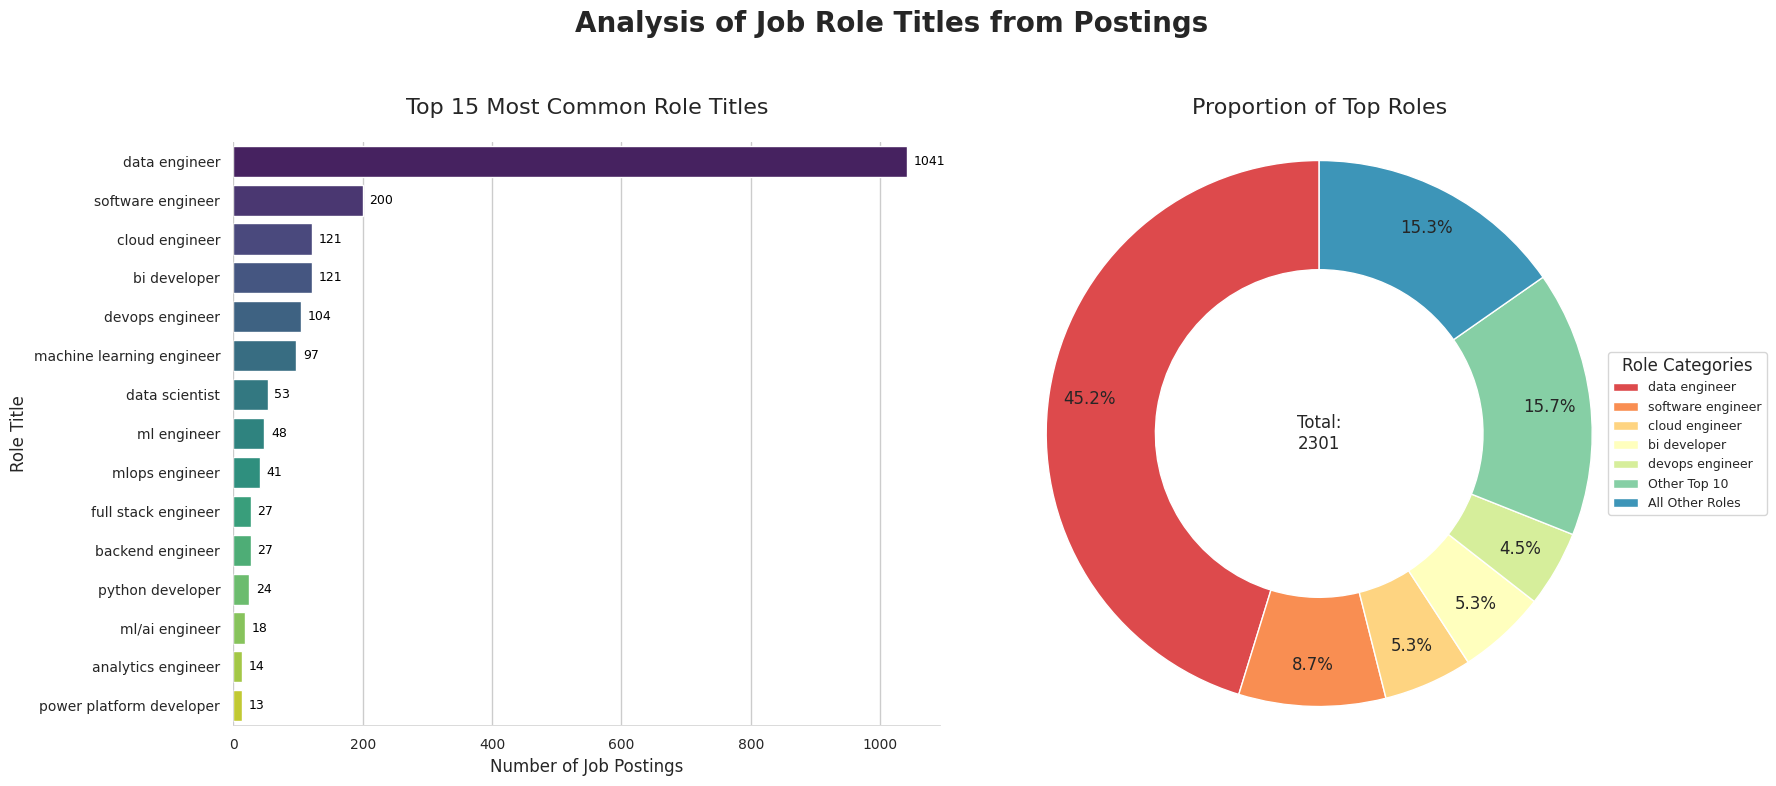

In [6]:
role_titles_series = df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_title'))
cleaned_role_titles = role_titles_series.astype(str).str.strip().str.lower().replace('none', 'unknown')
top_role_titles = cleaned_role_titles.value_counts().nlargest(15)
# --- End of your data preparation ---

# --- Plotting ---
# Set a nicer global style (optional, but recommended for aesthetics)
sns.set_theme(style="whitegrid") # "whitegrid" or "white" or "darkgrid"

fig, axes = plt.subplots(1, 2, figsize=(18, 8)) # 1 row, 2 columns

# --- Plot 1: Improved Bar Chart of Top 15 Role Titles ---
ax1 = axes[0]
barplot = sns.barplot(y=top_role_titles.index, x=top_role_titles.values, palette="viridis", ax=ax1, orient='h')
ax1.set_title('Top 15 Most Common Role Titles', fontsize=16, pad=20)
ax1.set_xlabel('Number of Job Postings', fontsize=12)
ax1.set_ylabel('Role Title', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)
ax1.tick_params(axis='x', labelsize=10)

# Add annotations (counts on bars)
for i, v in enumerate(top_role_titles.values):
    ax1.text(v + (top_role_titles.values.max() * 0.01), i, str(v), color='black', va='center', fontweight='medium', fontsize=9)

# Cleaner spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(0.5)
ax1.spines['bottom'].set_linewidth(0.5)

# Subtle horizontal grid (Seaborn's whitegrid style already does this, but if you use "white")
# ax1.grid(axis='x', linestyle='--', alpha=0.7)


# --- Plot 2: Donut Chart for Proportion of Top 15 Roles ---
ax2 = axes[1]
total_roles_count = len(cleaned_role_titles)
top_15_sum = top_role_titles.sum()
other_roles_count = total_roles_count - top_15_sum

labels_pie = list(top_role_titles.index[:5]) + ['Other Top 10'] + ['All Other Roles'] # Show top 5, then group next 10
sizes_pie = list(top_role_titles.values[:5]) + [top_role_titles.values[5:].sum()] + [other_roles_count]
# If you want all 15 explicitly + 'Other':
# labels_pie = list(top_role_titles.index) + ['All Other Roles']
# sizes_pie = list(top_role_titles.values) + [other_roles_count]


# Explode the 'All Other Roles' slice slightly if you want
explode = [0] * (len(sizes_pie) -1) + [0.05] # explode the last slice

# Colors: Use a different palette or a subset of viridis
colors = sns.color_palette("Spectral", len(sizes_pie)) # "Spectral", "coolwarm", "icefire"

wedges, texts, autotexts = ax2.pie(
    sizes_pie,
    labels=None, # We'll add custom legend
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85, # Distance of percentage text from center
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w') # For donut chart
)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax2.axis('equal')
ax2.set_title('Proportion of Top Roles', fontsize=16, pad=20)

# Add a legend for the pie/donut chart
# To avoid clutter, only show legend for the main categories we defined
ax2.legend(wedges, labels_pie, title="Role Categories", loc="center left", bbox_to_anchor=(0.9, 0, 0.5, 1), fontsize=9)

# Add a center text for the donut chart (optional)
ax2.text(0, 0, f'Total:\n{total_roles_count}', ha='center', va='center', fontsize=12)


# --- Overall Figure Settings ---
fig.suptitle('Analysis of Job Role Titles from Postings', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for suptitle
plt.show()

In [7]:
df_bq

,job_summary,company_information,location_and_work_model,required_qualifications,preferred_qualifications,role_context,benefits,job_id
0,"{'role_title': 'DevOps Engineer', 'role_object...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '0', 'experience_year...","{'skills_keywords': [], 'other_notes': 'Not Sp...","{'collaboration_with': [], 'team_structure': '...","{'training_development': 'Not Specified', 'lea...",4203796028
1,"{'role_title': 'Software Developer', 'role_obj...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '3', 'experience_year...","{'skills_keywords': [], 'other_notes': 'Intere...","{'collaboration_with': ['Network', 'Security',...",{'training_development': 'Support the resoluti...,4209830737
2,"{'role_title': 'Machine Learning Engineer', 'r...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...","{'skills_keywords': ['Vertex AI', 'dbt (Data B...",{'collaboration_with': ['cross-functional team...,"{'training_development': 'Not Specified', 'lea...",4194898848
3,"{'role_title': 'Machine Learning Engineer', 'r...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...","{'skills_keywords': ['DBT', 'Vertex AI'], 'oth...",{'collaboration_with': ['cross-functional team...,"{'training_development': 'Not Specified', 'lea...",4194898848
4,"{'role_title': 'Machine Learning Engineer', 'r...","{'company_type': 'Unspecified / Generic Tech',...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...","{'skills_keywords': ['DBT', 'Vertex AI'], 'oth...",{'collaboration_with': ['cross-functional team...,"{'training_development': 'Not Specified', 'lea...",4194898848
...,...,...,...,...,...,...,...,...
2296,"{'role_title': 'Software Engineer', 'role_obje...","{'company_type': 'AI / Data Science Focused', ...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '0', 'experience_year...","{'skills_keywords': [], 'other_notes': 'None'}","{'collaboration_with': [], 'team_structure': '...","{'training_development': 'None', 'learning_pla...",4204842868
2297,"{'role_title': 'Software Engineer', 'role_obje...","{'company_type': 'AI / Data Science Focused', ...",{'specification_level': 'Specific Location / R...,"{'experience_years_min': '0', 'experience_year...","{'skills_keywords': [], 'other_notes': 'taxas ...","{'collaboration_with': [], 'team_structure': '...","{'training_development': 'string', 'learning_p...",4204842827
2298,"{'role_title': 'Data Engineer', 'role_objectiv...",{'company_type': 'Banking / Financial Institut...,{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...",{'skills_keywords': ['Open-Source Contribution...,"{'collaboration_with': [], 'team_structure': '...","{'training_development': 'Not Specified', 'lea...",4214749312
2299,"{'role_title': 'Data Engineer', 'role_objectiv...",{'company_type': 'Banking / Financial Institut...,{'specification_level': 'Specific Location / R...,"{'experience_years_min': '8', 'experience_year...","{'skills_keywords': ['Snowflake', 'Column-orie...","{'collaboration_with': [], 'team_structure': '...","{'training_development': 'Not Specified', 'lea...",4214749312


In [8]:
from IPython.display import display, HTML

role_titles_series = df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_title'))
cleaned_role_titles = role_titles_series.astype(str).str.strip().str.lower().replace('none', 'unknown')
# --- End of your data preparation ---

# 1. Identify Top 3 Roles
top_3_roles = cleaned_role_titles.value_counts().nlargest(3).index.tolist()
print(f"Top 3 roles selected: {top_3_roles}")

# 2. Prepare data for analysis: Create a DataFrame with roles and their responsibilities
df_analysis = pd.DataFrame({
    'role': cleaned_role_titles,
    'responsibilities': df_bq['role_context'].apply(lambda x: safe_get(x, 'key_responsibilities', []) if isinstance(safe_get(x, 'key_responsibilities'), list) else [])
})
df_top_roles_responsibilities = df_analysis[df_analysis['role'].isin(top_3_roles)].copy()

# 3. Explode and Clean Responsibilities
df_exploded = df_top_roles_responsibilities.explode('responsibilities')
df_exploded['responsibilities'] = df_exploded['responsibilities'].astype(str).str.strip().str.lower()
# Remove empty or placeholder responsibilities more robustly
placeholders_resp_to_remove = ['', 'none', 'nan', 'n/a', 'not specified']
df_exploded = df_exploded[~df_exploded['responsibilities'].isin(placeholders_resp_to_remove) & df_exploded['responsibilities'].notna()]


# 4. Get Top 5 Responsibilities per Role
N_TOP_RESPONSIBILITIES = 5 # Define N for responsibilities
top_responsibilities_by_role = {}
for role_name in top_3_roles:
    role_specific_data = df_exploded[df_exploded['role'] == role_name]
    if not role_specific_data.empty:
        top_n_resp = role_specific_data['responsibilities'].value_counts().nlargest(N_TOP_RESPONSIBILITIES)
        if not top_n_resp.empty:
            top_responsibilities_by_role[role_name] = top_n_resp
# --- End of data prep ---


# 5. Displaying as Styled Tables (replaces the plotting section)
if not top_responsibilities_by_role:
    print("No responsibilities found for the top roles to display.")
else:
    # Define some CSS styles for reuse (same as before, can be defined once globally in your notebook)
    table_attributes = 'style="border-collapse: collapse; width: 95%; margin: 20px auto; font-family: Arial, sans-serif; box-shadow: 0 4px 8px 0 rgba(0,0,0,0.1);"'
    # caption_style = "font-size: 1.3em; font-weight: bold; color: #333; margin-bottom: 10px; text-align: center;" # For separate caption
    header_style = [{'selector': 'th',
                     'props': [('background-color', '#007bff'), # A nice blue for responsibilities
                               ('color', 'white'),
                               ('font-weight', 'bold'),
                               ('text-align', 'center'),
                               ('padding', '12px 10px'), # Slightly more padding
                               ('border', '1px solid #0056b3')]}]
    cell_style = [{'selector': 'td',
                   'props': [('padding', '10px 8px'),
                             ('border', '1px solid #ddd'),
                             ('text-align', 'left'),
                             ('white-space', 'normal'),
                             ('word-wrap', 'break-word'),
                             ('max-width', '600px') # Max width for responsibility column
                            ]}]

    # Add a main title for this section using HTML
    display(HTML(f'<h2 style="text-align:center; color:#333; font-family: Arial, sans-serif;">Key Responsibilities Breakdown for Top Job Roles</h2>'))

    for role_name, responsibilities_counts in top_responsibilities_by_role.items():
        # No need for the print statement above the table if the caption is clear
        # print(f"\n--- Top {N_TOP_RESPONSIBILITIES} Key Responsibilities for: {role_name.title()} ---")
        df_display_resp = pd.DataFrame(responsibilities_counts).reset_index()
        df_display_resp.columns = ['Responsibility', 'Frequency']

        styled_df_resp = (df_display_resp.style
                     .set_table_attributes(table_attributes)
                     .set_caption(f"Top {N_TOP_RESPONSIBILITIES} Responsibilities for {role_name.title()}")
                     .set_table_styles(header_style + cell_style)
                     .set_properties(subset=['Responsibility'], **{'text-align': 'left', 'font-size': '0.95em', 'vertical-align': 'top'})
                     .set_properties(subset=['Frequency'], **{'text-align': 'center', 'font-weight': 'bold', 'vertical-align': 'middle'})
                     .bar(subset=['Frequency'], color='#28a745', vmin=0, align='mid') # Green bars, align can be 'left', 'mid', 'zero'
                     .format({'Frequency': "{:.0f}"})
                     .hide(axis="index")
                    )
        display(styled_df_resp)
        # display(HTML("<br>")) # Add some space between tables if needed

Top 3 roles selected: ['data engineer', 'software engineer', 'cloud engineer']


Responsibility,Frequency
recommend ways to efficiently provide quality data and added value.,22
"develop, maintain, and support data pipelines.",22
ensure architecture meets business requirements.,20
"prioritize and manage multiple projects simultaneously, meeting deadlines and delivering high-quality results.",18
"extraction of data from various sources, including databases, file systems, and apis",17


Responsibility,Frequency
avaliar e classificar os códigos gerados por modelos de ia.,11
criar e responder a perguntas relacionadas à ciência da computação para ajudar no treinamento de modelos de ia.,11
actively participate in code and design reviews to maintain exceptional quality and deepen your understanding of the system architecture and implementation,11
"helping grow the team by participating in recruiting, mentoring and developing best practices",10
"integrating third-party apis from exchanges, wallets, and infrastructure providers",7


Responsibility,Frequency
"monitoring, troubleshooting, and optimizing aws infrastructure and services to ensure maximum performance and reliability.",8
developing and maintaining ci/cd pipelines using jenkins to streamline deployment processes.,8
automating infrastructure provisioning and configuration management using tools like ansible and terraform.,8
"ensuring compliance with security best practices and helping implement robust access controls using iam, kms, and other aws security services.",8
creating and maintaining infrastructure as code (iac) with cloudformation or terraform to ensure consistent and reproducible deployments.,8


In [9]:
role_titles_series = df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_title'))
cleaned_role_titles = role_titles_series.astype(str).str.strip().str.lower().replace('none', 'unknown')

top_3_roles = cleaned_role_titles.value_counts().nlargest(3).index.tolist()
print(f"Top 3 roles selected for objectives analysis: {top_3_roles}")

N_TOP_OBJECTIVES = 5
# --- End of previous code ---


# 2. Prepare data for objectives analysis
df_objectives_analysis = pd.DataFrame({
    'role': cleaned_role_titles,
    'objective_string': df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_objective', '')) # Correct key
})

# Clean the objective strings: strip whitespace and convert to lowercase
df_objectives_analysis['objective_string'] = df_objectives_analysis['objective_string'].astype(str).str.strip().str.lower()

# Define a list of placeholder strings to remove (case-insensitive due to previous .lower())
placeholders_to_remove = ['n/a', 'not specified', 'none', 'nan', ''] # Added 'none' and 'nan' just in case

# Remove rows where the objective string became empty after cleaning OR is a placeholder
df_objectives_analysis = df_objectives_analysis[
    ~df_objectives_analysis['objective_string'].isin(placeholders_to_remove) & # Not in the list of placeholders
    df_objectives_analysis['objective_string'].notna() # Still good to keep for robustness
]

# Filter for only the top 3 roles
df_top_roles_objectives = df_objectives_analysis[df_objectives_analysis['role'].isin(top_3_roles)].copy()


# --- (Rest of the code: Debug prints, Step 4, Step 5 for plotting - remains the same) ---

# Debug: Check the content of df_top_roles_objectives
# print("\nContent of df_top_roles_objectives after filtering and cleaning:")
# print(df_top_roles_objectives.head())
# print(f"Number of rows in df_top_roles_objectives: {len(df_top_roles_objectives)}")
# for role_name in top_3_roles:
# print(f"\nObjective strings for role '{role_name}':")
# print(df_top_roles_objectives[df_top_roles_objectives['role'] == role_name]['objective_string'].value_counts().head(10))


# 4. For each of the top 3 roles, get the top N unique objective strings
top_objectives_by_role = {}
for role_name in top_3_roles:
    role_specific_data = df_top_roles_objectives[df_top_roles_objectives['role'] == role_name]
    if not role_specific_data.empty:
        top_n = role_specific_data['objective_string'].value_counts().nlargest(N_TOP_OBJECTIVES)
        if not top_n.empty:
            top_objectives_by_role[role_name] = top_n

# Define some CSS styles for reuse
table_attributes = 'style="border-collapse: collapse; width: 95%; margin: 20px auto; font-family: Arial, sans-serif; box-shadow: 0 4px 8px 0 rgba(0,0,0,0.1);"'
caption_style = "font-size: 1.3em; font-weight: bold; color: #333; margin-bottom: 10px; text-align: center;"
header_style = [{'selector': 'th',
                 'props': [('background-color', '#4CAF50'), # A pleasant green
                           ('color', 'white'),
                           ('font-weight', 'bold'),
                           ('text-align', 'center'),
                           ('padding', '10px 8px'),
                           ('border', '1px solid #ddd')]}]
cell_style = [{'selector': 'td',
               'props': [('padding', '8px'),
                         ('border', '1px solid #ddd'),
                         ('text-align', 'left'), # Default for all cells
                         ('white-space', 'normal'), # Allow text wrapping
                         ('word-wrap', 'break-word'), # Ensure long words break
                         ('max-width', '500px') # Max width for objective column before wrapping
                        ]}]


for role_name, objective_counts in top_objectives_by_role.items():
    print(f"\n--- Top {N_TOP_OBJECTIVES} Role Objectives for: {role_name.title()} ---") # This print can be removed if you prefer only the HTML table
    df_display = pd.DataFrame(objective_counts).reset_index()
    df_display.columns = ['Objective', 'Frequency']

    # Apply styles
    styled_df = (df_display.style
                 .set_table_attributes(table_attributes)
                 .set_caption(f"Top Objectives for {role_name.title()}")
                 .set_table_styles(header_style + cell_style)
                 .set_properties(subset=['Objective'], **{'text-align': 'left', 'font-size': '0.95em'})
                 .set_properties(subset=['Frequency'], **{'text-align': 'center', 'font-weight': 'bold'})
                 .bar(subset=['Frequency'], color='#5cb85c', vmin=0) # Light green bars for frequency
                 .format({'Frequency': "{:.0f}"}) # Ensure frequency is displayed as integer
                 .hide(axis="index") # Pandas 2.1.0+ for hide(), older use .hide_index()
                )

    # To ensure caption style is applied correctly (Styler caption has limited CSS control directly)
    # We can prepend the caption as an HTML string.
    # display(HTML(f'<div style="{caption_style}">{styled_df.caption}</div>')) # Display caption separately styled
    # styled_df.set_caption(None) # Remove the styler's caption if displaying separately

    display(styled_df)
    print("\n") # For spacing between tables if printing multiple

Top 3 roles selected for objectives analysis: ['data engineer', 'software engineer', 'cloud engineer']

--- Top 5 Role Objectives for: Data Engineer ---


Objective,Frequency
"this role is focused on designing, developing, and maintaining the data platform required for data storage, processing, orchestration, and analysis.",22
"in this role, you will be instrumental in designing, building, and maintaining robust data infrastructures that support our clients' data-driven initiatives.",11
"vamos reforçar a nossa área de data&ai, que tem suportado milhares de clientes na evolução/criação das suas plataformas de dados, analítica e ia",11
"help them launch innovative digital products that interact with hundreds of millions of customers, transactions and data points.",9
utilise advanced data analytics to grow canonical's product adoption and market penetration,9





--- Top 5 Role Objectives for: Software Engineer ---


Objective,Frequency
building dremio parts and features which will power our ability to serve data as data products assisted by ai.,4
your role will contribute to shaping ai-powered customer experiences and enhancing the efficiency of our service platforms.,4
"help build and maintain one of our most important internal systems - a platform responsible for orchestrating and automating the movement of assets across exchanges, wallets, and custodians such as binance, okx, fireblocks, kucoin, and coinbase",4
"design, develop, and implement java-based applications for our automotive distribution and retail systems",3
expanding and enhancing our leading 'miles enterprise' solution.,3





--- Top 5 Role Objectives for: Cloud Engineer ---


Objective,Frequency
"collaborating with development teams to design, implement, and optimize highly available, scalable, and secure cloud solutions on aws.",9
"play a pivotal role in designing, implementing, and maintaining robust cloud solutions in aws",7
"estamos a reforçar a nossa equipa para um projeto inovador e de grande impacto, onde terás a oportunidade de trabalhar num ambiente dinâmico, desafiante e tecnologicamente avançado.",5
integrar um projeto aliciante em lisboa.,4
desenvolver e otimizar pipelines de dados na aws,3


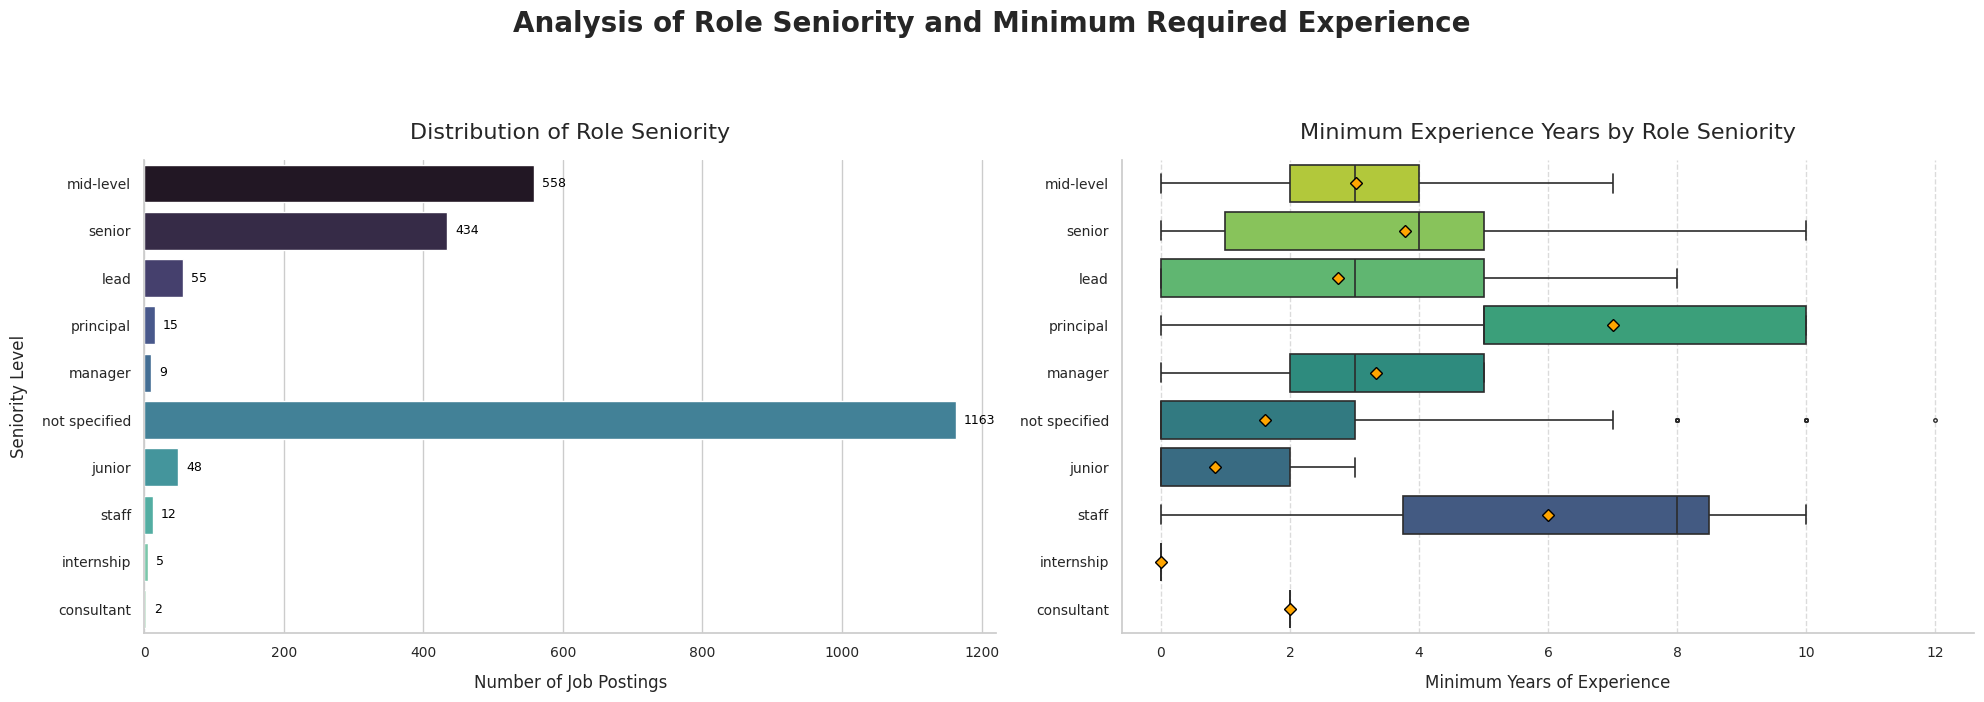

,Count,Mean,Q1,Median,Q3
seniority,,,,,
mid-level,558,3.0,2.0,3.0,4.0
senior,432,3.8,1.0,4.0,5.0
lead,55,2.7,0.0,3.0,5.0
principal,15,7.0,5.0,5.0,10.0
manager,9,3.3,2.0,3.0,5.0
not specified,1163,1.6,0.0,0.0,3.0
junior,48,0.8,0.0,0.0,2.0
staff,12,6.0,3.8,8.0,8.5
internship,5,0.0,0.0,0.0,0.0


In [10]:
# --- Part 1: Seniority Distribution Data ---
role_seniority_series = df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_seniority'))
cleaned_seniority = role_seniority_series.astype(str).str.strip().str.lower().replace('none', 'unknown')
cleaned_seniority = cleaned_seniority.replace('', 'unknown')
seniority_counts = cleaned_seniority.value_counts()

desired_seniority_order = ['entry', 'mid-level', 'senior', 'lead', 'principal', 'manager', 'unknown'] # Added manager
ordered_indices = [s for s in desired_seniority_order if s in seniority_counts.index]
remaining_indices = [s for s in seniority_counts.index if s not in ordered_indices]
final_order_seniority_plot = ordered_indices + remaining_indices

# --- Part 2: Seniority vs. Minimum Experience Years Data ---
df_exp = pd.DataFrame({
    'seniority': cleaned_seniority,
    'min_exp': df_bq['required_qualifications'].apply(lambda x_dict: safe_get(x_dict, 'experience_years_min'))
    # 'max_exp' is removed
})

def to_numeric_safe(series):
    return pd.to_numeric(series, errors='coerce')

df_exp['min_exp_numeric'] = to_numeric_safe(df_exp['min_exp'])

# Filter for plotting and stats: exclude 'unknown' seniority and rows where min_exp is NaN
df_exp_plot = df_exp[df_exp['seniority'] != 'unknown'].copy()
df_exp_plot.dropna(subset=['min_exp_numeric'], inplace=True) # Drop if min_exp_numeric is NaN

# Order for the experience plot and table (based on available data in df_exp_plot)
final_order_exp_analysis = [s for s in final_order_seniority_plot if s in df_exp_plot['seniority'].unique() and s != 'unknown']


# --- Plotting in Two Columns ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # Adjusted height slightly

# --- Plot 1: Distribution of Role Seniority ---
ax1 = axes[0]
if not final_order_seniority_plot or seniority_counts.loc[final_order_seniority_plot].empty:
    ax1.text(0.5, 0.5, "No seniority data to display", ha='center', va='center', fontsize=12)
else:
    sns.barplot(y=seniority_counts.loc[final_order_seniority_plot].index,
                x=seniority_counts.loc[final_order_seniority_plot].values,
                palette="mako",
                order=final_order_seniority_plot,
                ax=ax1)
    for i, v_count in enumerate(seniority_counts.loc[final_order_seniority_plot].values):
        offset = seniority_counts.loc[final_order_seniority_plot].values.max() * 0.01
        ax1.text(v_count + offset, i, str(v_count), color='black', va='center', fontsize=9)
ax1.set_title('Distribution of Role Seniority', fontsize=16, pad=15)
ax1.set_xlabel('Number of Job Postings', fontsize=12, labelpad=10)
ax1.set_ylabel('Seniority Level', fontsize=12, labelpad=10)
ax1.tick_params(axis='both', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Plot 2: Seniority vs. Minimum Experience Years (Box Plot) ---
ax2 = axes[1]
if df_exp_plot.empty or not final_order_exp_analysis:
    ax2.text(0.5, 0.5, "No minimum experience data\nto display for selected seniorities", ha='center', va='center', fontsize=12, linespacing=1.5)
else:
    sns.boxplot(x='min_exp_numeric', y='seniority',
                data=df_exp_plot,
                palette="viridis_r", # Changed palette
                order=final_order_exp_analysis,
                ax=ax2,
                linewidth=1.2,
                fliersize=2.5,
                showmeans=True,
                meanprops={"marker":"D", # Diamond for mean
                           "markerfacecolor":"orange",
                           "markeredgecolor":"black",
                           "markersize":"6"})
    ax2.grid(axis='x', linestyle='--', alpha=0.7)
ax2.set_title('Minimum Experience Years by Role Seniority', fontsize=16, pad=15)
ax2.set_xlabel('Minimum Years of Experience', fontsize=12, labelpad=10)
ax2.set_ylabel('') # Y-axis is clear from seniority levels
ax2.tick_params(axis='y', labelsize=10)
ax2.tick_params(axis='x', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Overall Figure Settings ---
fig.suptitle('Analysis of Role Seniority and Minimum Required Experience', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


# --- Part 3: Descriptive Statistics Table ---
if df_exp_plot.empty or not final_order_exp_analysis:
    print("\nNo data available to generate the experience statistics table.")
else:
    summary_stats = df_exp_plot.groupby('seniority')['min_exp_numeric'].agg(
        Count='count',
        Mean='mean',
        Q1=lambda x: x.quantile(0.25),
        Median='median', # Q2
        Q3=lambda x: x.quantile(0.75)
    ).reindex(final_order_exp_analysis).dropna(how='all') # Order and remove rows if all stats are NaN

    if summary_stats.empty:
        print("\nNo data available to generate the experience statistics table after ordering.")
    else:
        # Styling for the summary table
        table_attributes_stats = 'style="border-collapse: collapse; width: 80%; margin: 25px auto; font-family: Arial, sans-serif; box-shadow: 0 2px 6px 0 rgba(0,0,0,0.1);"'
        header_style_stats = [{'selector': 'th',
                            'props': [('background-color', '#6c757d'), # Bootstrap secondary grey
                                      ('color', 'white'),
                                      ('font-weight', 'bold'),
                                      ('text-align', 'center'),
                                      ('padding', '10px 8px'),
                                      ('border', '1px solid #5a6268')]}]
        cell_style_stats = [{'selector': 'td',
                        'props': [('padding', '8px'),
                                    ('border', '1px solid #ddd'),
                                    ('text-align', 'right') ]}] # Right align numbers
        index_name_style_stats = [{'selector': 'th.row_heading', # For the index name (Seniority)
                                'props': [('text-align', 'left'), ('font-weight', 'bold')]}]

        styled_summary_table = (summary_stats.style
                            .set_table_attributes(table_attributes_stats)
                            .set_caption("Summary Statistics for Minimum Experience Years by Seniority")
                            .set_table_styles(header_style_stats + cell_style_stats + index_name_style_stats)
                            .set_properties(subset=pd.IndexSlice[:, ['Mean', 'Q1', 'Median', 'Q3']], **{'text-align': 'center'})
                            .format({ # Format numeric columns
                                'Mean': "{:.1f}",
                                'Q1': "{:.1f}",
                                'Median': "{:.1f}",
                                'Q3': "{:.1f}",
                                'Count': "{:.0f}"
                            })
                           )
        display(HTML('<h3 style="text-align:center; color:#333; font-family: Arial, sans-serif; margin-top: 20px;">Summary of Minimum Experience Requirements</h3>'))
        display(styled_summary_table)

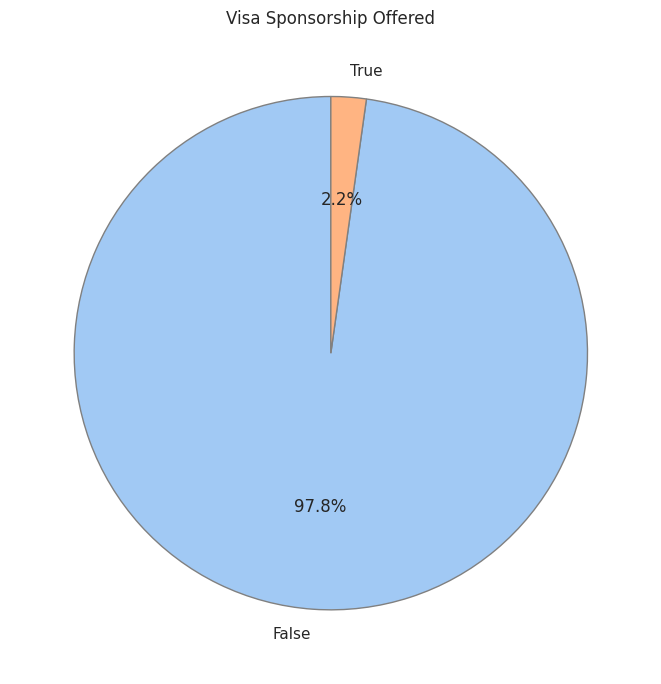

In [11]:
visa_sponsorship_series = df_bq['job_summary'].apply(lambda x: safe_get(x, 'visa_sponsorship'))
def map_visa_status(status):
  if status is True: return 'True'
  if status is False: return 'False'
  return 'Unknown' # Catches None and any other oddities

sponsorship_status = visa_sponsorship_series.apply(map_visa_status)
sponsorship_counts = sponsorship_status.value_counts()


if not sponsorship_counts.empty:
    plt.figure(figsize=(7, 7)) # Pie charts often look better square-ish
    sponsorship_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"),
                            wedgeprops={'edgecolor': 'gray'}) # Add edge for clarity
    plt.title('Visa Sponsorship Offered')
    plt.ylabel('') # Hide the y-label
    plt.tight_layout()
    plt.show()
else:
    print("No visa sponsorship data to plot.")

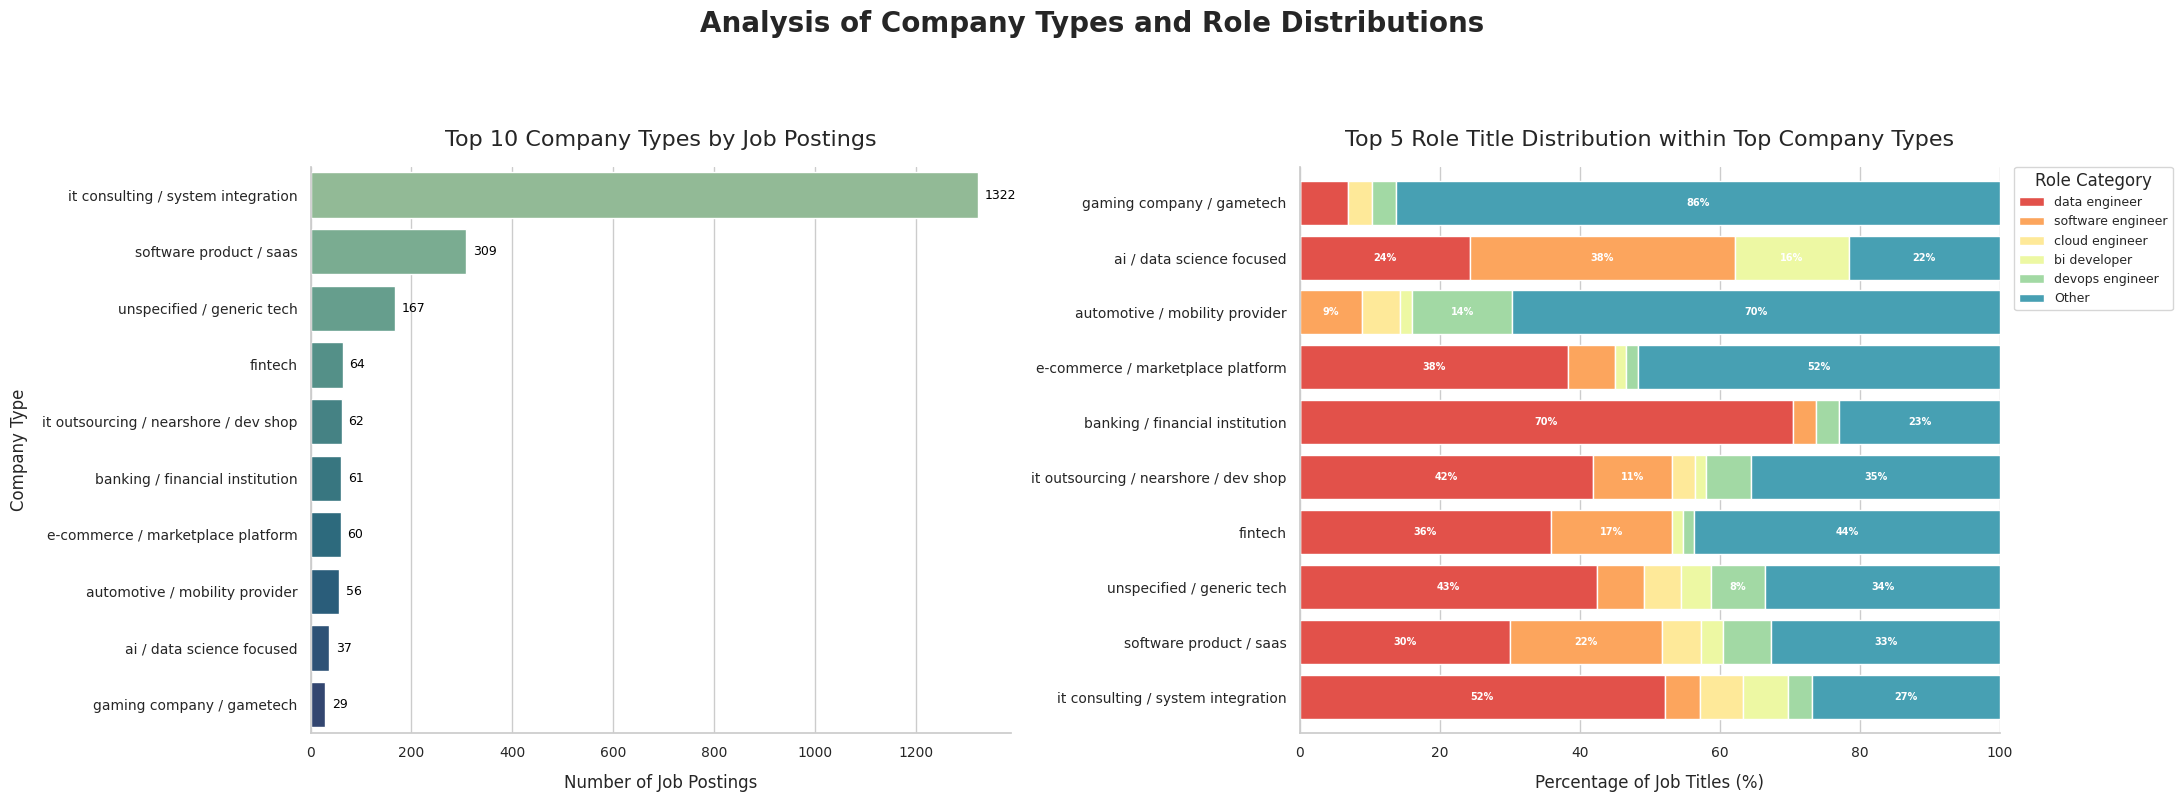

In [12]:
# --- Part 1: Top Company Types Data ---
company_types_series = df_bq['company_information'].apply(lambda x: safe_get(x, 'company_type'))
cleaned_company_types = company_types_series.astype(str).str.strip().str.lower().replace('none', 'unknown')
cleaned_company_types = cleaned_company_types.replace('', 'unknown')
company_type_counts = cleaned_company_types.value_counts().nlargest(10)
# Get the list of top 10 company types for filtering later
top_10_company_type_names = company_type_counts.index.tolist()


# --- Part 2: Role Title Distribution within Top Company Types ---
# 1. Get all role titles and clean them
role_titles_series_all = df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_title'))
cleaned_role_titles_all = role_titles_series_all.astype(str).str.strip().str.lower().replace('none', 'unknown')
cleaned_role_titles_all = cleaned_role_titles_all.replace('', 'unknown')

# 2. Identify Top 5 Role Titles globally
top_5_role_titles = cleaned_role_titles_all.value_counts().nlargest(5).index.tolist()

# 3. Create a DataFrame with cleaned company types and categorized role titles
df_roles_by_comp = pd.DataFrame({
    'company_type': cleaned_company_types,
    'role_title_raw': cleaned_role_titles_all
})

# Categorize role titles: Top 5 or 'Other'
df_roles_by_comp['role_category'] = df_roles_by_comp['role_title_raw'].apply(
    lambda x: x if x in top_5_role_titles else 'Other'
)

# Filter to include only the top 10 company types for the stacked bar chart
df_roles_by_comp_filtered = df_roles_by_comp[df_roles_by_comp['company_type'].isin(top_10_company_type_names)]

# 4. Group by company_type and role_category to get counts
role_dist_counts = df_roles_by_comp_filtered.groupby(['company_type', 'role_category']).size().unstack(fill_value=0)

# 5. Calculate percentages within each company type
role_dist_percentage = role_dist_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Ensure the order of company types in the stacked bar matches the first plot
role_dist_percentage = role_dist_percentage.reindex(top_10_company_type_names).dropna(how='all')

# Ensure consistent order for role categories in the stack (Top 5 then Other)
role_category_order = top_5_role_titles + ['Other']
# Filter to only those present in columns and maintain order
role_category_order_plot = [rc for rc in role_category_order if rc in role_dist_percentage.columns]
# Add any remaining columns not in the defined order (shouldn't happen if logic is correct)
# remaining_rc_cols = [rc for rc in role_dist_percentage.columns if rc not in role_category_order_plot]
# role_category_order_plot += remaining_rc_cols

role_dist_percentage = role_dist_percentage[role_category_order_plot]


# --- Plotting in Two Columns ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(22, 8)) # Wider figure for two plots

# --- Plot 1: Top 10 Company Types ---
ax1 = axes[0]
if company_type_counts.empty:
    ax1.text(0.5, 0.5, "No company type data", ha='center', va='center')
else:
    sns.barplot(y=company_type_counts.index, x=company_type_counts.values, palette="crest", ax=ax1)
    # Add annotations
    for i, v_count in enumerate(company_type_counts.values):
        offset = company_type_counts.values.max() * 0.01
        ax1.text(v_count + offset, i, str(v_count), color='black', va='center', fontsize=9)
ax1.set_title('Top 10 Company Types by Job Postings', fontsize=16, pad=15)
ax1.set_xlabel('Number of Job Postings', fontsize=12, labelpad=10)
ax1.set_ylabel('Company Type', fontsize=12, labelpad=10)
ax1.tick_params(axis='both', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


# --- Plot 2: Stacked Percentage Bar Chart of Role Titles by Company Type ---
ax2 = axes[1]
if role_dist_percentage.empty:
    ax2.text(0.5, 0.5, "No role distribution data\nfor top company types", ha='center', va='center', linespacing=1.5)
else:
    # Define a color palette for roles (Top 5 + Other)
    # Using a qualitative palette that's distinct
    num_role_categories = len(role_category_order_plot)
    role_palette = sns.color_palette("Spectral", n_colors=num_role_categories) # Or "tab10", "Set2"

    role_dist_percentage.plot(kind='barh', stacked=True, ax=ax2, colormap=None, color=role_palette, width=0.8)

    ax2.set_title('Top 5 Role Title Distribution within Top Company Types', fontsize=16, pad=15)
    ax2.set_xlabel('Percentage of Job Titles (%)', fontsize=12, labelpad=10)
    ax2.set_ylabel('') # Y-axis labels (company types) are already there
    ax2.tick_params(axis='both', labelsize=10)
    ax2.legend(title='Role Category', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=9)
    ax2.set_xlim(0, 100) # Percentages sum to 100

    # Add percentage annotations on the bars (can be tricky for stacked)
    for i, company_type_bar in enumerate(role_dist_percentage.index):
        cumulative_width = 0
        for j, role_cat in enumerate(role_dist_percentage.columns):
            percentage_value = role_dist_percentage.loc[company_type_bar, role_cat]
            if percentage_value > 0: # Only annotate if there's a value
                # Calculate the center of the segment
                segment_center_x = cumulative_width + (percentage_value / 2)
                # Display text if segment is wide enough
                if percentage_value > 7: # Threshold for displaying text to avoid clutter
                     ax2.text(segment_center_x, i, f"{percentage_value:.0f}%",
                             ha='center', va='center', color='white', fontsize=7, fontweight='bold')
            cumulative_width += percentage_value

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)


# --- Overall Figure Settings ---
fig.suptitle('Analysis of Company Types and Role Distributions', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

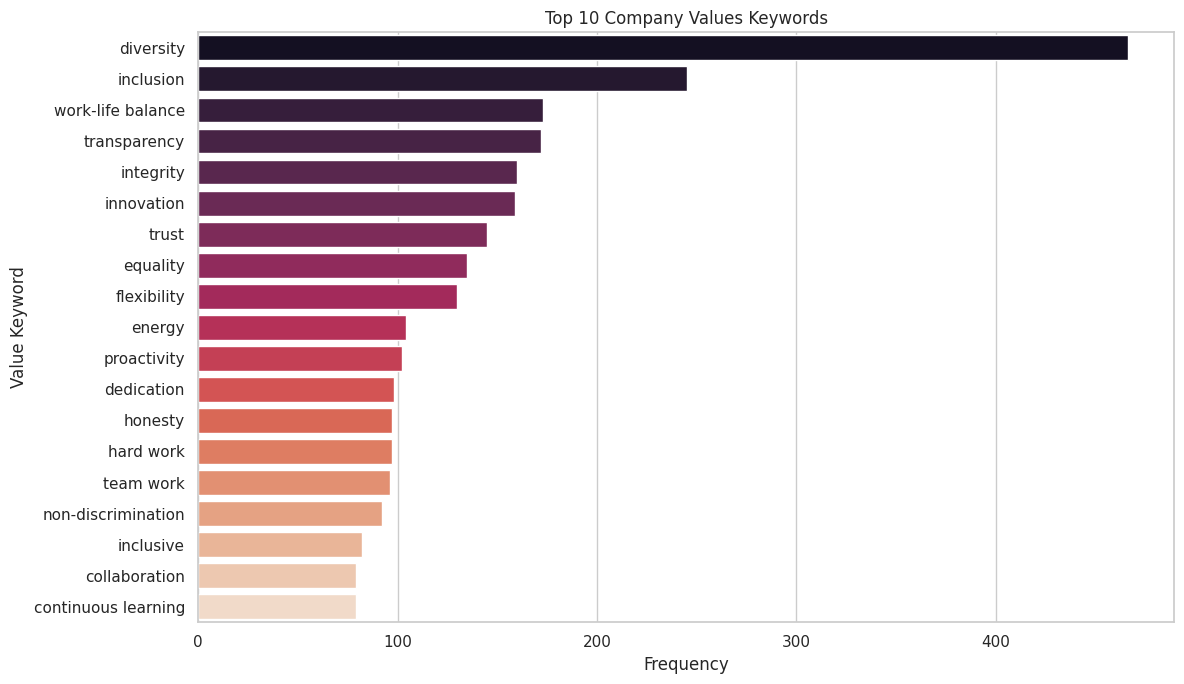

In [13]:
import re

top_company_values = explode_and_count(df_bq, 'company_information.company_values_keywords', top_n=20)
if 'unknown' in top_company_values:
    del top_company_values['unknown']

if not top_company_values.empty:
    plt.figure()
    sns.barplot(y=top_company_values.index, x=top_company_values.values, palette="rocket")
    plt.title('Top 10 Company Values Keywords')
    plt.xlabel('Frequency')
    plt.ylabel('Value Keyword')
    plt.tight_layout()
    plt.show()
else:
    print("No company values keywords data to plot.")

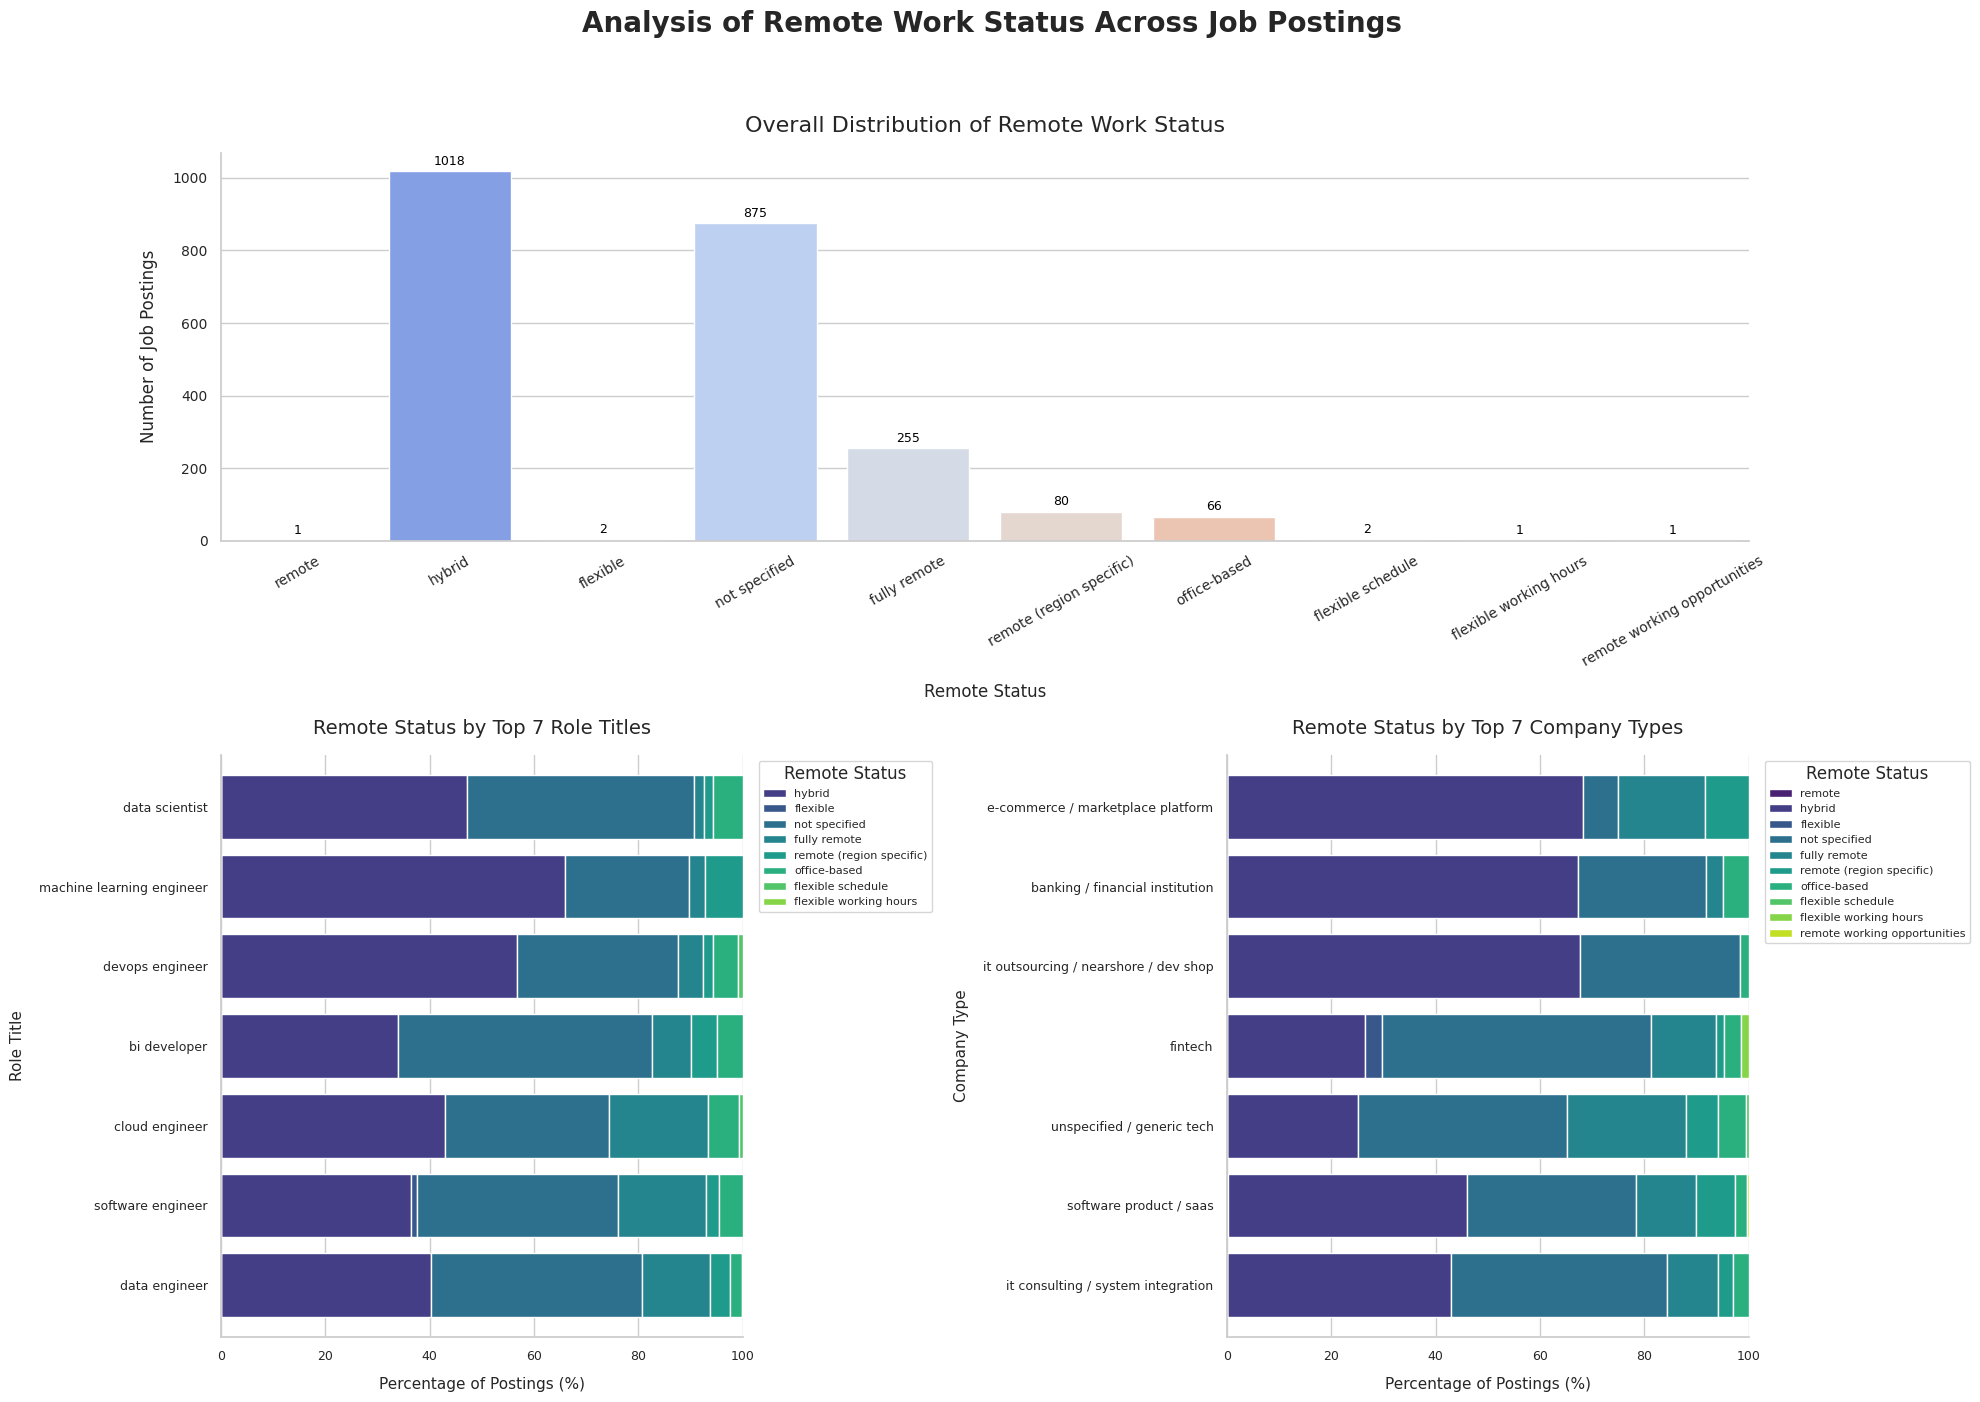

In [14]:
# --- 1. Overall Remote Status ---
remote_status_series = df_bq['location_and_work_model'].apply(lambda x: safe_get(x, 'remote_status'))
cleaned_remote_status = remote_status_series.astype(str).str.strip().str.lower().replace('none', 'unknown')
cleaned_remote_status = cleaned_remote_status.replace('', 'unknown')
remote_status_counts = cleaned_remote_status.value_counts()
remote_order = ['remote', 'hybrid', 'flexible', 'on-site', 'unknown']
ordered_remote_indices = [s for s in remote_order if s in remote_status_counts.index]
remaining_remote_indices = [s for s in remote_status_counts.index if s not in ordered_remote_indices]
final_remote_order_overall = ordered_remote_indices + remaining_remote_indices

# --- 2. Data Preparation for Breakdowns ---
role_titles_s = df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_title')).astype(str).str.strip().str.lower().replace('none', 'unknown').replace('', 'unknown')
company_types_s = df_bq['company_information'].apply(lambda x: safe_get(x, 'company_type')).astype(str).str.strip().str.lower().replace('none', 'unknown').replace('', 'unknown')
df_analysis_remote = pd.DataFrame({
    'remote_status': cleaned_remote_status,
    'role_title': role_titles_s,
    'company_type': company_types_s
})
N_TOP_CATEGORIES = 7

# --- 2a. Remote Status by Top Role Titles ---
top_role_titles_rs = df_analysis_remote['role_title'].value_counts().nlargest(N_TOP_CATEGORIES).index.tolist()
df_roles_filtered = df_analysis_remote[df_analysis_remote['role_title'].isin(top_role_titles_rs)]
if not df_roles_filtered.empty:
    remote_by_role_counts = df_roles_filtered.groupby(['role_title', 'remote_status']).size().unstack(fill_value=0)
    remote_by_role_perc = remote_by_role_counts.apply(lambda x: x / x.sum() * 100, axis=1)
    cols_ordered_role = [col for col in final_remote_order_overall if col in remote_by_role_perc.columns]
    remaining_cols_role = [col for col in remote_by_role_perc.columns if col not in cols_ordered_role] # Add any missing remote status columns
    remote_by_role_perc = remote_by_role_perc.reindex(columns=cols_ordered_role + remaining_cols_role).fillna(0)
    remote_by_role_perc = remote_by_role_perc.reindex(top_role_titles_rs) # Ensure order of roles
else:
    remote_by_role_perc = pd.DataFrame()

# --- 2b. Remote Status by Top Company Types ---
top_company_types_rs = df_analysis_remote['company_type'].value_counts().nlargest(N_TOP_CATEGORIES).index.tolist()
df_comp_filtered = df_analysis_remote[df_analysis_remote['company_type'].isin(top_company_types_rs)]
if not df_comp_filtered.empty:
    remote_by_comp_counts = df_comp_filtered.groupby(['company_type', 'remote_status']).size().unstack(fill_value=0)
    remote_by_comp_perc = remote_by_comp_counts.apply(lambda x: x / x.sum() * 100, axis=1)
    cols_ordered_comp = [col for col in final_remote_order_overall if col in remote_by_comp_perc.columns]
    remaining_cols_comp = [col for col in remote_by_comp_perc.columns if col not in cols_ordered_comp] # Add any missing remote status columns
    remote_by_comp_perc = remote_by_comp_perc.reindex(columns=cols_ordered_comp + remaining_cols_comp).fillna(0)
    remote_by_comp_perc = remote_by_comp_perc.reindex(top_company_types_rs) # Ensure order of company types
else:
    remote_by_comp_perc = pd.DataFrame()

# --- 3. Plotting ---
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])
ax_overall = fig.add_subplot(gs[0, :])
ax_roles = fig.add_subplot(gs[1, 0])
ax_companies = fig.add_subplot(gs[1, 1])

# Plot 1: Overall Remote Status Distribution
if remote_status_counts.empty or not final_remote_order_overall :
    ax_overall.text(0.5, 0.5, "No remote status data", ha='center', va='center')
else:
    # Ensure all categories in final_remote_order_overall are present in remote_status_counts index before .loc
    valid_order_for_loc = [idx for idx in final_remote_order_overall if idx in remote_status_counts.index]
    if not valid_order_for_loc: # If somehow all ordered items are missing
        sns.barplot(x=remote_status_counts.index,
                    y=remote_status_counts.values,
                    palette="coolwarm", ax=ax_overall)
        print("Warning: Could not apply custom order to overall remote status plot as ordered items were not found in data.")
    else:
        sns.barplot(x=remote_status_counts.loc[valid_order_for_loc].index,
                    y=remote_status_counts.loc[valid_order_for_loc].values,
                    palette="coolwarm", ax=ax_overall, order=valid_order_for_loc) # Use order here as well

    ax_overall.set_title('Overall Distribution of Remote Work Status', fontsize=16, pad=15)
    ax_overall.set_xlabel('Remote Status', fontsize=12, labelpad=10)
    ax_overall.set_ylabel('Number of Job Postings', fontsize=12, labelpad=10)
    # CORRECTED LINE: Removed 'ha' from tick_params
    ax_overall.tick_params(axis='x', rotation=30, labelsize=10) # Rotation mode 'anchor' is default for > 0 rotation
    # For more explicit control of alignment WITH rotation, you might do:
    # plt.setp(ax_overall.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
    ax_overall.tick_params(axis='y', labelsize=10)
    # Annotations for overall plot
    values_to_annotate = remote_status_counts.loc[valid_order_for_loc].values if valid_order_for_loc else remote_status_counts.values
    max_val_overall = values_to_annotate.max() if len(values_to_annotate) > 0 else 1
    for i, v in enumerate(values_to_annotate):
        ax_overall.text(i, v + (max_val_overall * 0.01), str(v), color='black', ha='center', va='bottom', fontsize=9)

ax_overall.spines['top'].set_visible(False)
ax_overall.spines['right'].set_visible(False)

# Common palette for stacked bars (remote statuses)
# Ensure all remote statuses from data are included in the map, using final_remote_order_overall as preferred order
all_present_remote_statuses = pd.concat([
    pd.Series(remote_by_role_perc.columns),
    pd.Series(remote_by_comp_perc.columns)
]).unique().tolist()

ordered_palette_keys = [status for status in final_remote_order_overall if status in all_present_remote_statuses]
ordered_palette_keys += [status for status in all_present_remote_statuses if status not in ordered_palette_keys]


if ordered_palette_keys: # Check if there are any keys for the palette
    remote_status_palette_options = sns.color_palette("viridis", n_colors=len(ordered_palette_keys))
    remote_status_color_map = {status: color for status, color in zip(ordered_palette_keys, remote_status_palette_options)}
else:
    remote_status_color_map = {}


# Plot 2: Remote Status by Top Role Titles
if remote_by_role_perc.empty:
    ax_roles.text(0.5, 0.5, "No data for remote status by role", ha='center', va='center', linespacing=1.5)
else:
    # Ensure columns for plotting exist and are in the desired order
    plot_cols_role = [col for col in ordered_palette_keys if col in remote_by_role_perc.columns]
    remote_by_role_perc[plot_cols_role].plot(kind='barh', stacked=True, ax=ax_roles,
                             color=[remote_status_color_map.get(col, '#CCCCCC') for col in plot_cols_role],
                             width=0.8)
    ax_roles.set_title(f'Remote Status by Top {N_TOP_CATEGORIES} Role Titles', fontsize=14, pad=15)
    ax_roles.set_xlabel('Percentage of Postings (%)', fontsize=11, labelpad=10)
    ax_roles.set_ylabel('Role Title', fontsize=11, labelpad=10)
    ax_roles.tick_params(axis='both', labelsize=9)
    ax_roles.legend(title='Remote Status', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax_roles.set_xlim(0, 100)
    ax_roles.spines['top'].set_visible(False)
    ax_roles.spines['right'].set_visible(False)

# Plot 3: Remote Status by Top Company Types
if remote_by_comp_perc.empty:
    ax_companies.text(0.5, 0.5, "No data for remote status by company type", ha='center', va='center', linespacing=1.5)
else:
    # Ensure columns for plotting exist and are in the desired order
    plot_cols_comp = [col for col in ordered_palette_keys if col in remote_by_comp_perc.columns]
    remote_by_comp_perc[plot_cols_comp].plot(kind='barh', stacked=True, ax=ax_companies,
                             color=[remote_status_color_map.get(col, '#CCCCCC') for col in plot_cols_comp],
                             width=0.8)
    ax_companies.set_title(f'Remote Status by Top {N_TOP_CATEGORIES} Company Types', fontsize=14, pad=15)
    ax_companies.set_xlabel('Percentage of Postings (%)', fontsize=11, labelpad=10)
    ax_companies.set_ylabel('Company Type', fontsize=11, labelpad=10)
    ax_companies.tick_params(axis='both', labelsize=9)
    ax_companies.legend(title='Remote Status', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax_companies.set_xlim(0, 100)
    ax_companies.spines['top'].set_visible(False)
    ax_companies.spines['right'].set_visible(False)

fig.suptitle('Analysis of Remote Work Status Across Job Postings', fontsize=20, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

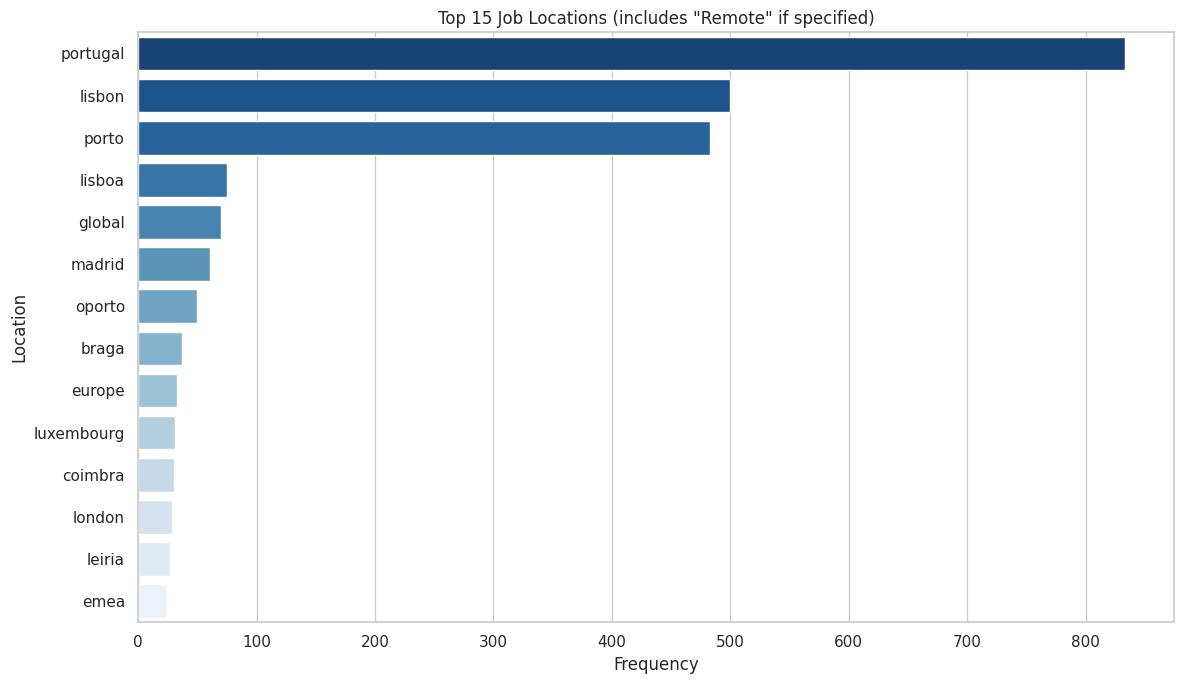

In [15]:
top_locations = explode_and_count(df_bq, 'location_and_work_model.locations', top_n=15)
if 'unknown' in top_locations:
    del top_locations['unknown']

if not top_locations.empty:
    plt.figure()
    sns.barplot(y=top_locations.index, x=top_locations.values, palette="Blues_r")
    plt.title('Top 15 Job Locations (includes "Remote" if specified)')
    plt.xlabel('Frequency')
    plt.ylabel('Location')
    plt.tight_layout()
    plt.show()
else:
    print("No location data to plot.")

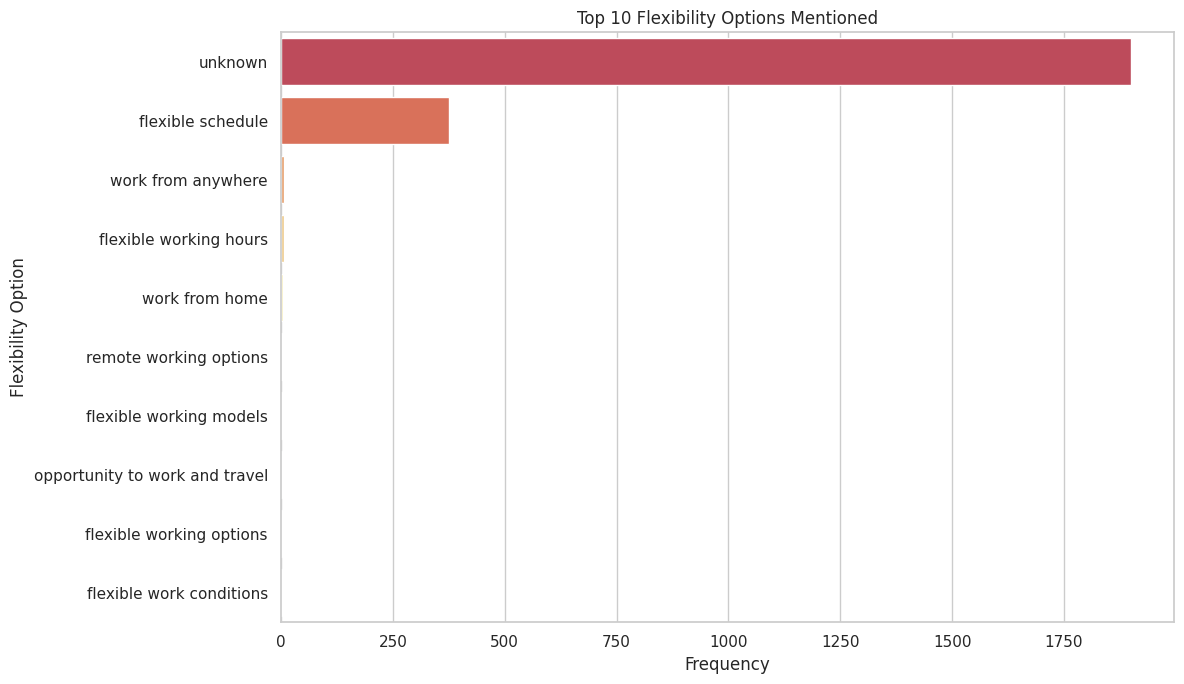

In [16]:
top_flexibility = explode_and_count(df_bq, 'location_and_work_model.flexibility', top_n=10)
if '[]' in top_flexibility:
    del top_flexibility['[]']

if not top_flexibility.empty:
    plt.figure()
    sns.barplot(y=top_flexibility.index, x=top_flexibility.values, palette="Spectral")
    plt.title('Top 10 Flexibility Options Mentioned')
    plt.xlabel('Frequency')
    plt.ylabel('Flexibility Option')
    plt.tight_layout()
    plt.show()
else:
    print("No flexibility data to plot.")

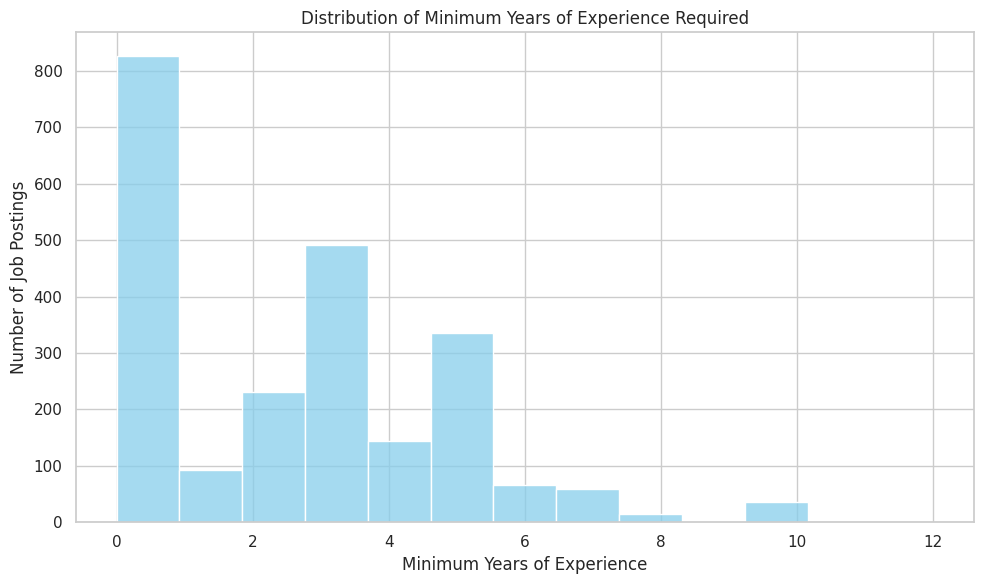

In [17]:
min_exp_series = df_bq['required_qualifications'].apply(lambda x: safe_get(x, 'experience_years_min'))
# Ensure numeric, coerce errors to NaN, then drop NaNs for plotting
min_exp_numeric = pd.to_numeric(min_exp_series, errors='coerce').dropna()


if not min_exp_numeric.empty:
    max_val = int(min_exp_numeric.max()) if not min_exp_numeric.empty else 10 # Ensure max_val is sensible
    plt.figure(figsize=(10,6))
    sns.histplot(min_exp_numeric, bins=max(10, min(20, max_val + 1)), kde=False, color="skyblue") # Dynamic bins
    plt.title('Distribution of Minimum Years of Experience Required')
    plt.xlabel('Minimum Years of Experience')
    plt.ylabel('Number of Job Postings')
    # plt.xticks(range(0, max_val + 2, 1)) # Only if discrete and few years
    plt.tight_layout()
    plt.show()
else:
    print("No valid minimum experience data to plot histogram.")

/tmp/ipykernel_166720/3989256479.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels_with_counts, rotation=45, ha="right") # Rotate for readability


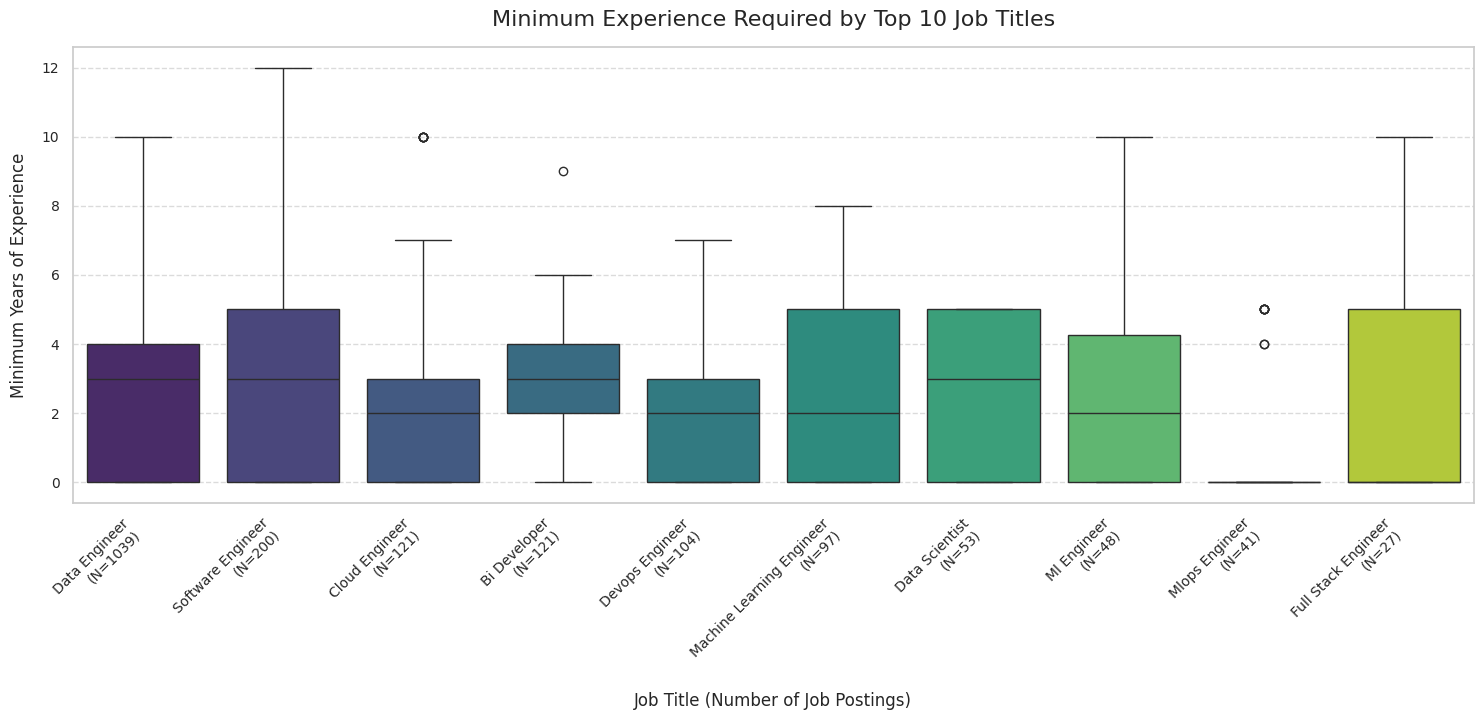

In [18]:
# --- 1. Data Extraction and Preparation ---
exp_data = df_bq['required_qualifications'].apply(lambda x: safe_get(x, 'experience_years_min'))
job_title_data = df_bq['job_summary'].apply(lambda x: safe_get(x, 'role_title'))

exp_job_title_df = pd.DataFrame({
    'min_experience': pd.to_numeric(exp_data, errors='coerce'),
    'job_title': job_title_data.astype(str).str.strip().str.lower().replace('none', 'unknown').replace('nan', 'unknown').replace('', 'unknown')
}).dropna(subset=['min_experience']) # Drop rows where min_experience is NaN

if not exp_job_title_df.empty:
    # --- 2. Identify Top N Job Titles and Define Order ---
    N_TOP_JOB_TITLES = 10 # Or 12, 15 - adjust for readability
    job_title_counts_for_plot = exp_job_title_df['job_title'].value_counts()
    top_n_job_titles_plot = job_title_counts_for_plot.nlargest(N_TOP_JOB_TITLES).index.tolist()

    # Filter the DataFrame to include only these top N job titles
    exp_job_title_df_filtered = exp_job_title_df[exp_job_title_df['job_title'].isin(top_n_job_titles_plot)]

    if not exp_job_title_df_filtered.empty:
        # --- 3. Create X-axis Labels with Frequencies for the Top N ---
        # Frequencies are for the filtered data (Top N job titles with valid experience)
        final_job_title_frequencies = exp_job_title_df_filtered['job_title'].value_counts().reindex(top_n_job_titles_plot).fillna(0).astype(int)

        xtick_labels_with_counts = []
        for job_title_level in top_n_job_titles_plot: # Iterate in the order of top N
            count = final_job_title_frequencies.get(job_title_level, 0)
            # Simple title case for labels, you might want more sophisticated capitalization
            label_text = ' '.join(word.capitalize() for word in job_title_level.split())
            # Truncate long job titles for the plot if necessary
            if len(label_text) > 25: # Adjust truncation length
                 label_text = label_text[:22] + "..."
            xtick_labels_with_counts.append(f"{label_text}\n(N={count})")

        # --- 4. Create the Plot ---
        plt.figure(figsize=(15, 8)) # Adjusted figsize for potentially more categories
        ax = sns.boxplot(x='job_title', y='min_experience', data=exp_job_title_df_filtered,
                         order=top_n_job_titles_plot, # Use the top N order
                         palette="viridis", # Changed palette
                         showfliers=True) # showfliers=True to show outliers, False to hide

        ax.set_xticklabels(xtick_labels_with_counts, rotation=45, ha="right") # Rotate for readability

        plt.title(f'Minimum Experience Required by Top {N_TOP_JOB_TITLES} Job Titles', fontsize=16, pad=15)
        plt.xlabel('Job Title (Number of Job Postings)', fontsize=12, labelpad=15) # Added padding
        plt.ylabel('Minimum Years of Experience', fontsize=12, labelpad=10)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        plt.grid(True, axis='y', linestyle='--', alpha=0.7) # Grid on y-axis for boxplot
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect for suptitle and labels
        plt.show()
    else:
        print("Not enough valid data for the top job titles to create the experience vs. job title box plot.")
else:
    print("Not enough valid data overall for experience vs. job title box plot.")

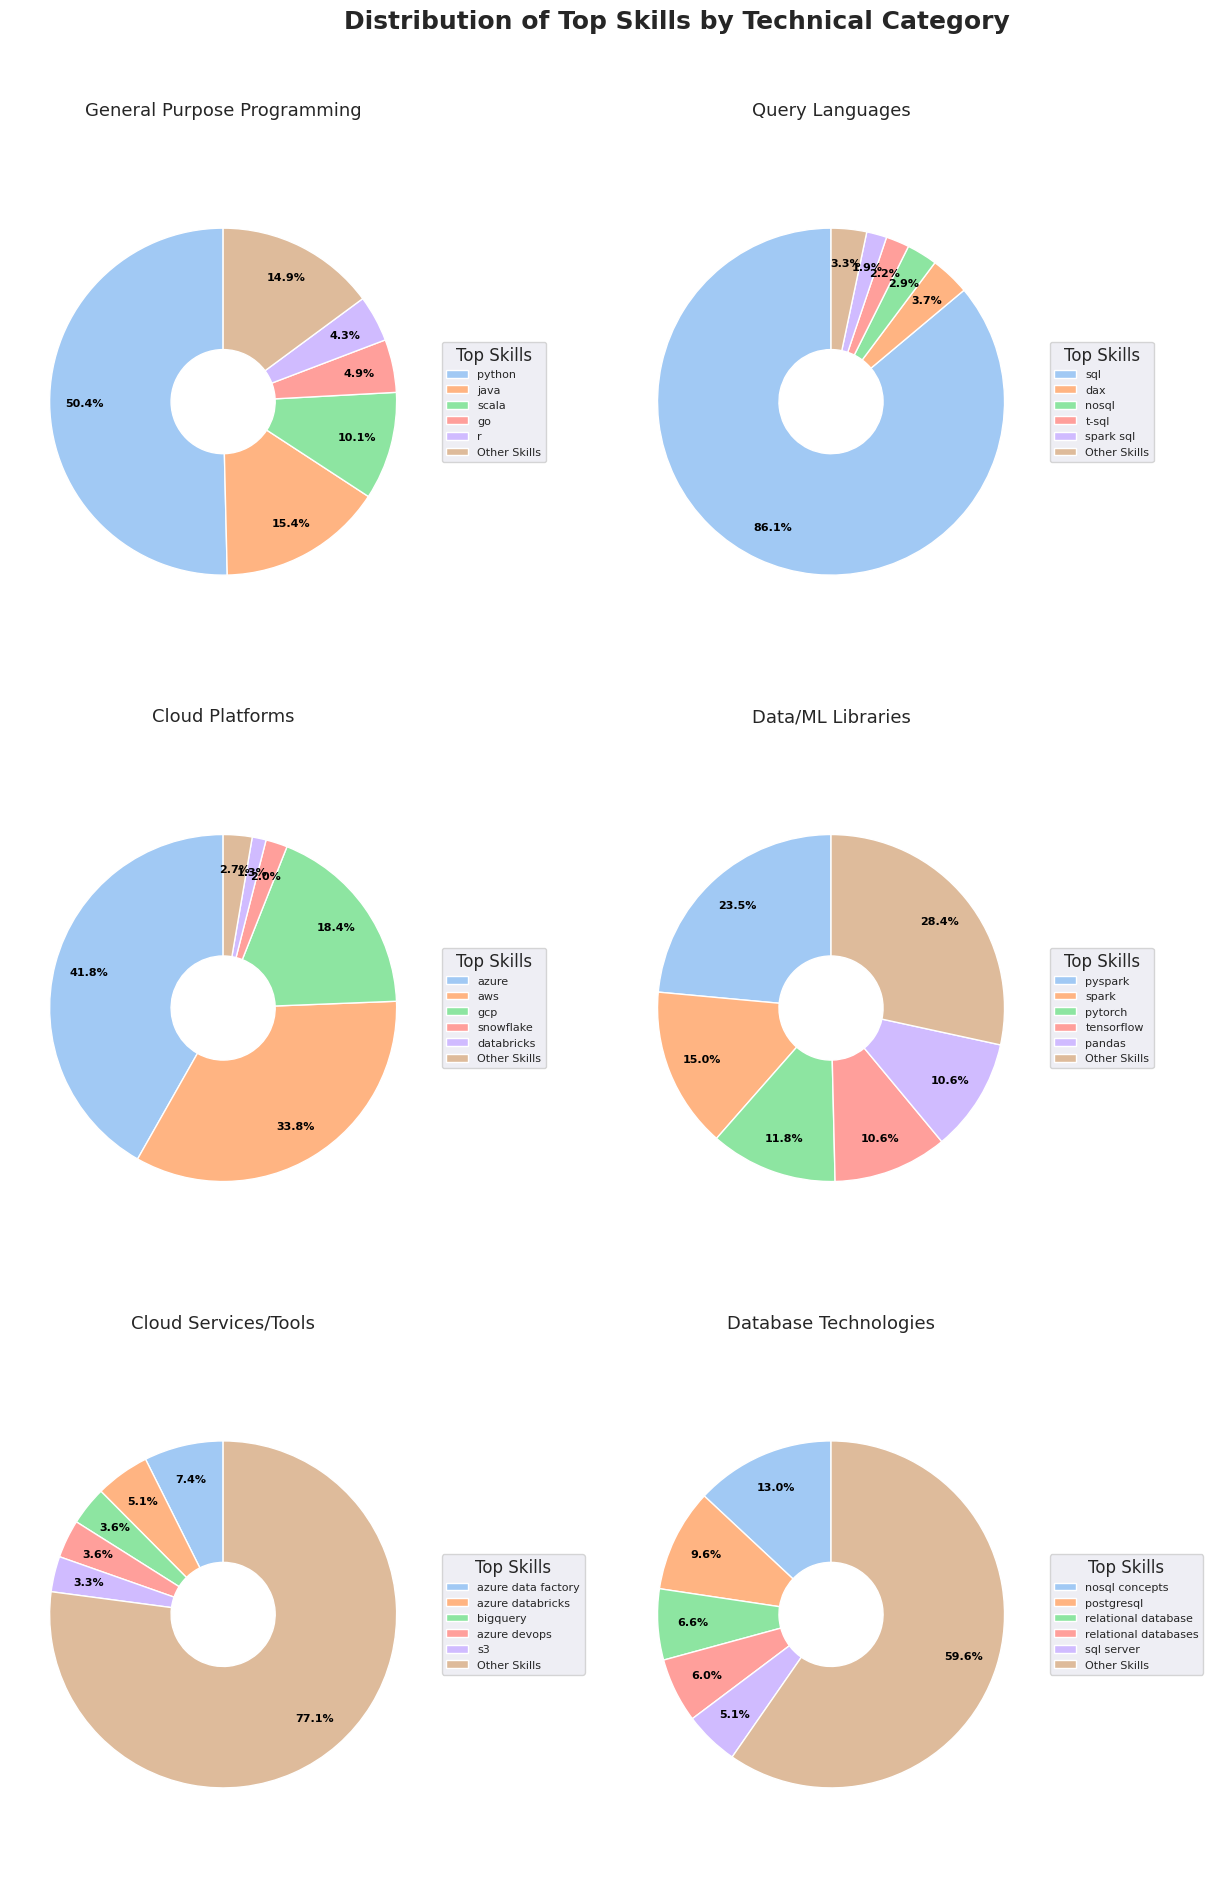

In [19]:
N_SLICES_PER_PIE = 6
NONE_VAL_REPLACEMENT = '[]' # Default for explode_and_count if needed
skill_categories_to_plot = {
    'General Purpose Programming': 'required_qualifications.technical_skills.programming_languages.general_purpose',
    'Query Languages': 'required_qualifications.technical_skills.programming_languages.query',
    'Cloud Platforms': 'required_qualifications.technical_skills.cloud_platforms',
    'Data/ML Libraries': 'required_qualifications.technical_skills.programming_languages.data_ml_libs',
    'Cloud Services/Tools': 'required_qualifications.technical_skills.cloud_services_tools',
    'Database Technologies': 'required_qualifications.technical_skills.database_technologies',
}
num_categories = len(skill_categories_to_plot)
if num_categories == 0:
    print("No skill categories defined to plot.")
else:
    sns.set_theme(palette="pastel")
    ncols = 2
    nrows = (num_categories + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 7, nrows * 6.5))

    if num_categories == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    plot_idx = 0
    for category_name, column_path in skill_categories_to_plot.items():
        current_ax = axes[plot_idx]

        all_skills_in_category_raw = explode_and_count(df_bq, column_path,
                                                       top_n=None,
                                                       none_val_replacement=NONE_VAL_REPLACEMENT)

        # Explicitly remove '[]' and other common string placeholders from the counts index
        # This is an additional safeguard if explode_and_count didn't catch everything
        # or if '[]' represents something specific you want to remove at this stage.
        placeholders_to_drop_from_index = ['[]', 'none', 'unknown', 'n/a', 'not specified', 'nan', ''] # ensure lowercase
        all_skills_in_category = all_skills_in_category_raw.drop(
            labels=[ph for ph in placeholders_to_drop_from_index if ph in all_skills_in_category_raw.index],
            errors='ignore'
        )

        if not all_skills_in_category.empty:
            if len(all_skills_in_category) > (N_SLICES_PER_PIE - 1):
                top_n_minus_1_skills = all_skills_in_category.head(N_SLICES_PER_PIE - 1)
                other_skills_sum = all_skills_in_category.iloc[N_SLICES_PER_PIE - 1:].sum()
                pie_data = top_n_minus_1_skills.copy()
                if other_skills_sum > 0:
                    pie_data.loc['Other Skills'] = other_skills_sum # Use .loc for adding to Series
            else:
                pie_data = all_skills_in_category.copy()

            if not pie_data.empty:
                pie_labels = [label[:20] + '...' if len(label) > 20 else label for label in pie_data.index]
                
                wedges, texts, autotexts = current_ax.pie(
                    pie_data.values,
                    labels=None,
                    autopct='%1.1f%%',
                    startangle=90,
                    pctdistance=0.80,
                    wedgeprops=dict(width=0.7, edgecolor='w')
                )
                current_ax.set_title(f'{category_name}', fontsize=13, pad=10)
                current_ax.axis('equal')
                plt.setp(autotexts, size=8, weight="bold", color="black")
                current_ax.legend(wedges, pie_labels,
                                  title="Top Skills",
                                  loc="center left",
                                  bbox_to_anchor=(1, 0, 0.5, 1),
                                  fontsize=8)
            else:
                current_ax.axis('off')
                current_ax.text(0.5, 0.5, f"No displayable data for\n{category_name}",
                                ha='center', va='center', fontsize=10, color='gray')
        else:
            current_ax.axis('off')
            current_ax.text(0.5, 0.5, f"No data found for\n{category_name}",
                            ha='center', va='center', fontsize=10, color='gray')
        plot_idx += 1

    for i in range(plot_idx, nrows * ncols):
        if i < len(axes):
            fig.delaxes(axes[i])

    plt.tight_layout(pad=2.0, rect=[0, 0, 0.9, 0.95])
    plt.suptitle('Distribution of Top Skills by Technical Category', fontsize=18, fontweight='bold')
    plt.show()

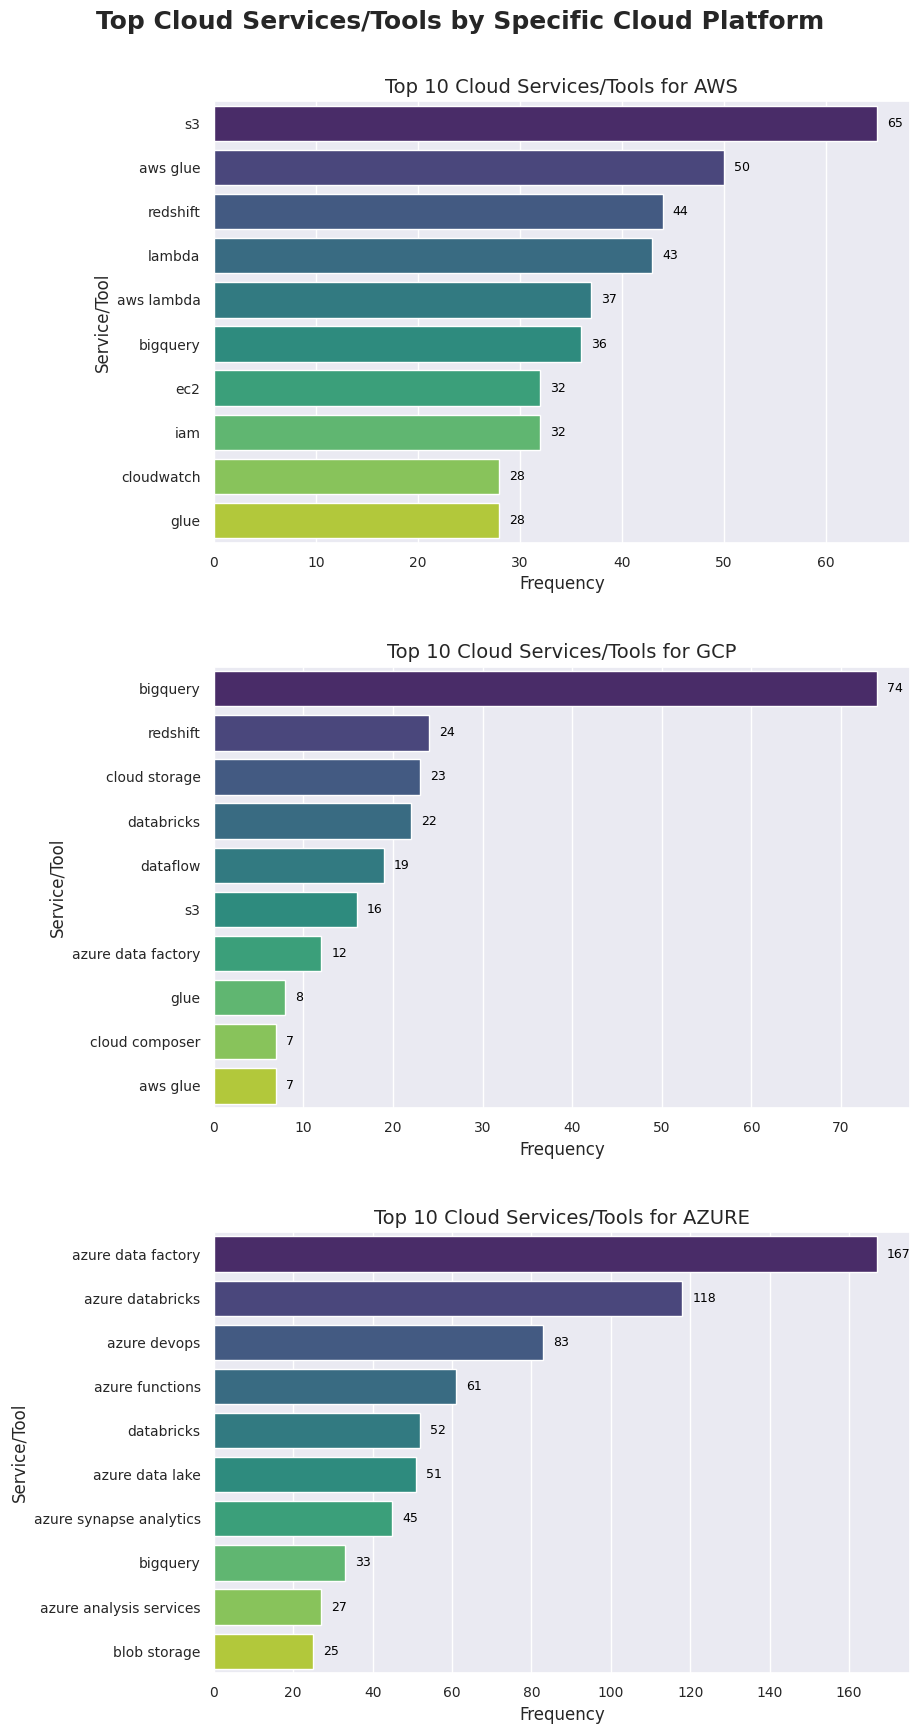

In [20]:
# --- Constants for this specific plotting task ---
TARGET_CLOUD_PLATFORMS = ['aws', 'gcp', 'azure']
CLOUD_PLATFORM_COLUMN_PATH = 'required_qualifications.technical_skills.cloud_platforms'
CLOUD_SERVICES_COLUMN_PATH = 'required_qualifications.technical_skills.cloud_services_tools'
N_TOP_SERVICES_PER_PLATFORM = 10
NONE_VAL_REPLACEMENT_SERVICES = '[]' # Placeholder for services, can be same as general one

def row_mentions_platform(row, platform_column_path, target_platform_name):
    """
    Checks if a given row mentions the target_platform_name in the specified column.
    Handles cases where the column might contain a string or a list of strings.
    Performs case-insensitive matching.
    """
    platform_data = safe_get(row, platform_column_path)
    if platform_data is None:
        return False

    target_lower = target_platform_name.lower()

    if isinstance(platform_data, str):
        return target_lower in platform_data.lower()
    elif isinstance(platform_data, list):
        return any(target_lower in str(item).lower() for item in platform_data)
    return False

num_target_platforms = len(TARGET_CLOUD_PLATFORMS)
if num_target_platforms == 0:
    print("No target cloud platforms specified for plotting.")
else:
    fig_plat, axes_plat = plt.subplots(nrows=num_target_platforms, ncols=1,
                                        figsize=(10, num_target_platforms * 6), squeeze=False)
    axes_plat = axes_plat.flatten()
    plot_idx = 0
    for platform_name in TARGET_CLOUD_PLATFORMS:
        current_ax = axes_plat[plot_idx]
        df_platform_specific = df_bq[
            df_bq.apply(lambda row: row_mentions_platform(row, CLOUD_PLATFORM_COLUMN_PATH, platform_name), axis=1)
        ].copy()
        if df_platform_specific.empty:
            print(f"No data found for platform: {platform_name}")
            current_ax.axis('off')
            current_ax.text(0.5, 0.5, f"No data found for\n{platform_name.upper()}",
                            horizontalalignment='center', verticalalignment='center',
                            fontsize=12, color='gray')
            plot_idx += 1
            continue
        top_services_for_platform = explode_and_count(
            df_platform_specific, CLOUD_SERVICES_COLUMN_PATH,
            top_n=N_TOP_SERVICES_PER_PLATFORM + 2,
            none_val_replacement=NONE_VAL_REPLACEMENT_SERVICES
        )
        placeholders_to_remove = [NONE_VAL_REPLACEMENT_SERVICES.lower(), '[]', '', 'unknown']
        for ph in placeholders_to_remove:
            if ph in top_services_for_platform.index:
                top_services_for_platform = top_services_for_platform.drop(ph, errors='ignore')
        final_top_services = top_services_for_platform.head(N_TOP_SERVICES_PER_PLATFORM)
        if not final_top_services.empty:
            sns.barplot(y=final_top_services.index, x=final_top_services.values,
                        ax=current_ax, palette="viridis")
            current_ax.set_title(f'Top {N_TOP_SERVICES_PER_PLATFORM} Cloud Services/Tools for {platform_name.upper()}', fontsize=14)
            current_ax.set_xlabel('Frequency', fontsize=12)
            current_ax.set_ylabel('Service/Tool', fontsize=12)
            current_ax.tick_params(axis='y', labelsize=10); current_ax.tick_params(axis='x', labelsize=10)
            for i, v in enumerate(final_top_services.values):
                current_ax.text(v + (final_top_services.values.max() * 0.015), # Adjusted offset slightly
                                i, str(int(v)), color='black', va='center', fontsize=9)
        else:
            current_ax.axis('off')
            current_ax.text(0.5, 0.5, f"No specific services data for\n{platform_name.upper()}",
                            horizontalalignment='center', verticalalignment='center',
                            fontsize=12, color='gray')
        plot_idx += 1
    for i in range(plot_idx, num_target_platforms):
        if i < len(axes_plat): fig_plat.delaxes(axes_plat[i])
    plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.97])
    fig_plat.suptitle(f'Top Cloud Services/Tools by Specific Cloud Platform',
                        fontsize=18, fontweight='bold')
    plt.show()

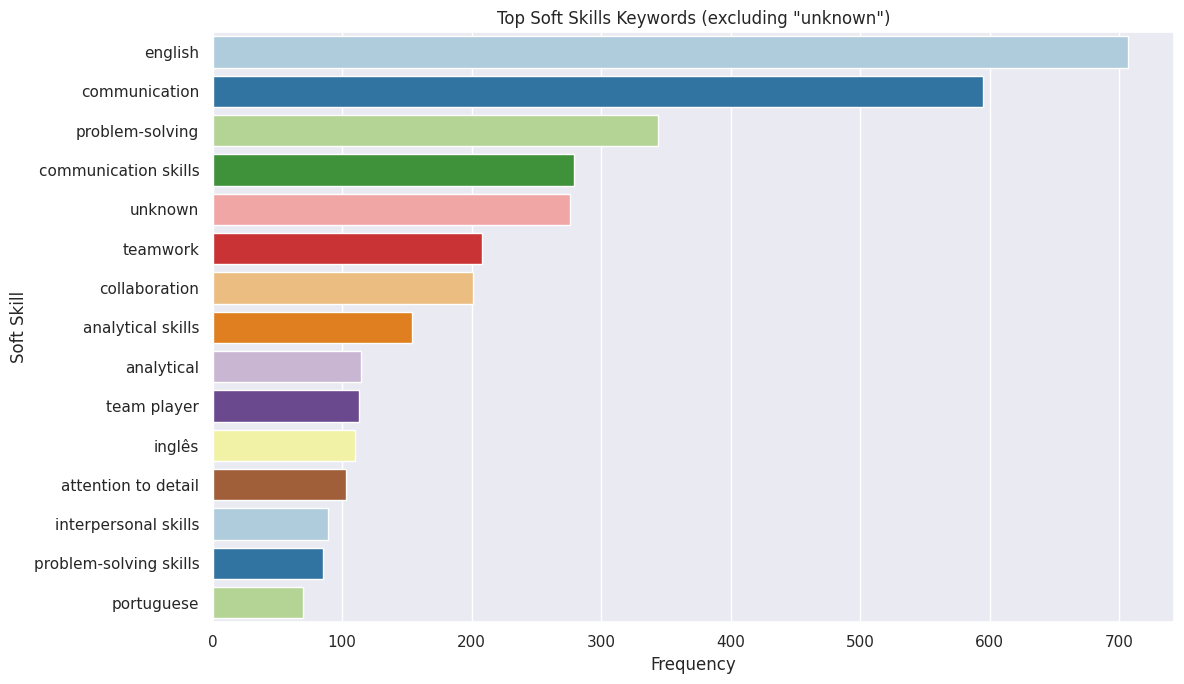

In [21]:
top_soft_skills = explode_and_count(df_bq, 'required_qualifications.soft_skills_keywords', top_n=15)
# Filter out 'unknown' if it appears due to empty lists
if '[]' in top_soft_skills:
  top_soft_skills = top_soft_skills.drop('[]', errors='ignore')


if not top_soft_skills.empty:
    plt.figure()
    sns.barplot(y=top_soft_skills.index, x=top_soft_skills.values, palette="Paired")
    plt.title('Top Soft Skills Keywords (excluding "unknown")')
    plt.xlabel('Frequency')
    plt.ylabel('Soft Skill')
    plt.tight_layout()
    plt.show()
else:
    print("No soft skills data to plot (or only 'unknown' found).")

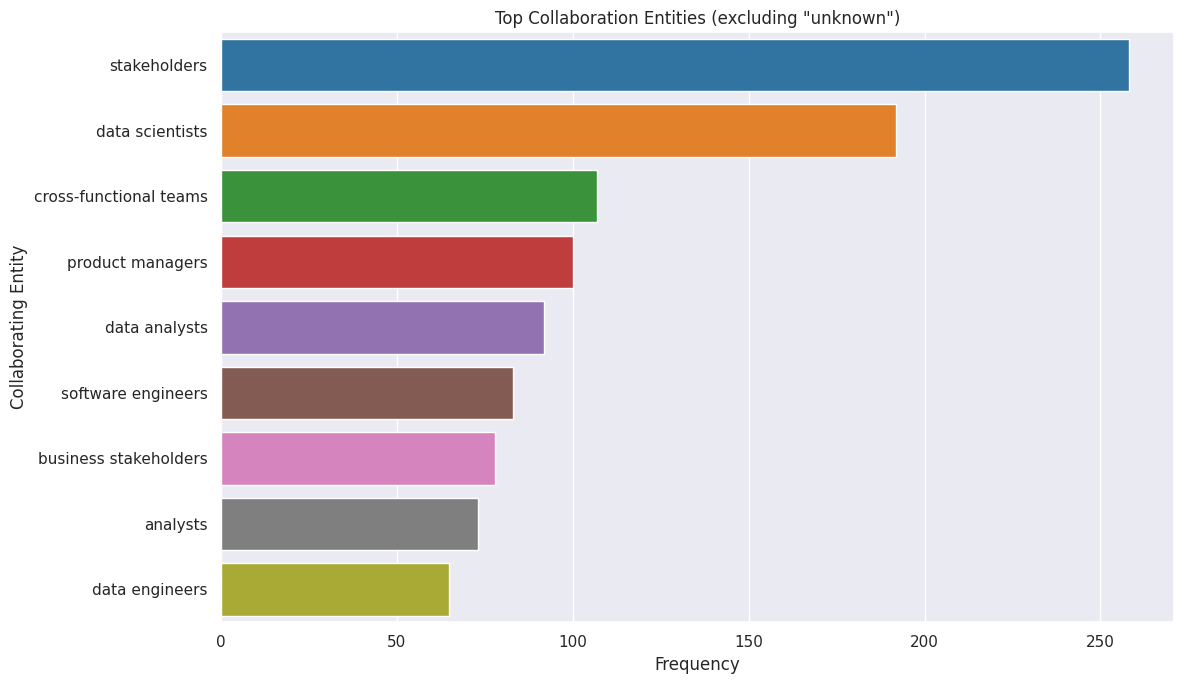

In [22]:
top_collaboration = explode_and_count(df_bq, 'role_context.collaboration_with', top_n=10)
if 'unknown' in top_collaboration:
  top_collaboration = top_collaboration.drop('unknown', errors='ignore')


if not top_collaboration.empty:
    plt.figure()
    sns.barplot(y=top_collaboration.index, x=top_collaboration.values, palette="tab10")
    plt.title('Top Collaboration Entities (excluding "unknown")')
    plt.xlabel('Frequency')
    plt.ylabel('Collaborating Entity')
    plt.tight_layout()
    plt.show()
else:
    print("No collaboration data to plot (or only 'unknown' found).")

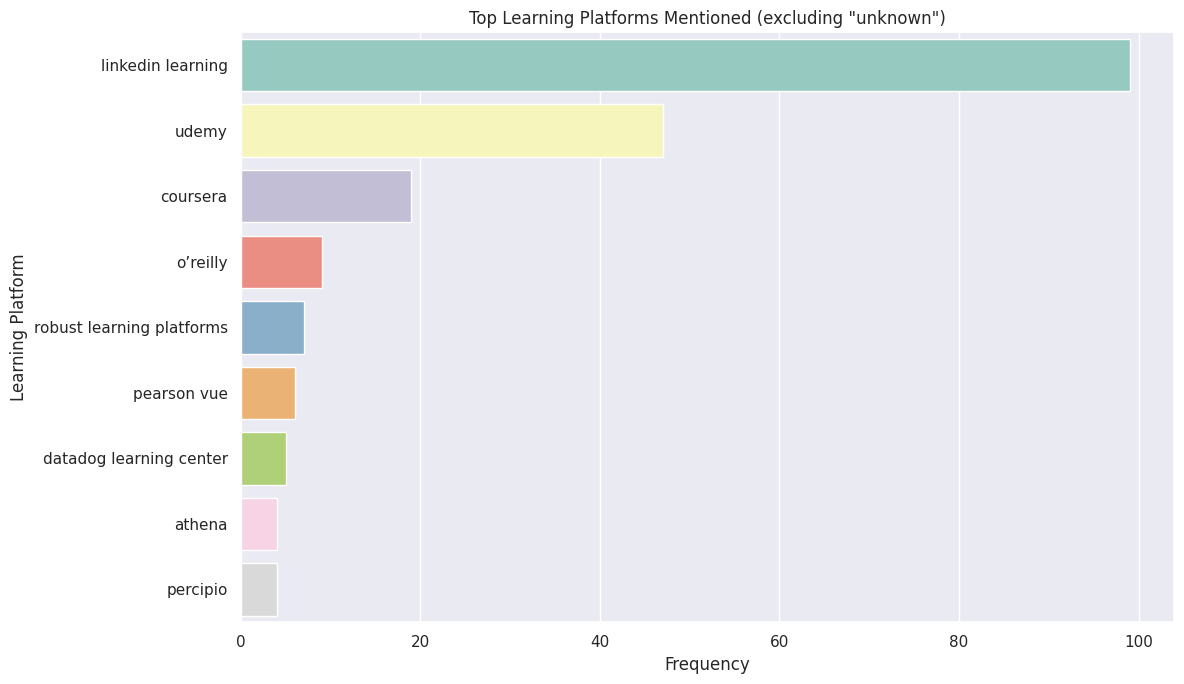

In [23]:
top_learning_platforms = explode_and_count(df_bq, 'benefits.learning_platforms', top_n=10)
if 'unknown' in top_learning_platforms:
  top_learning_platforms = top_learning_platforms.drop('unknown', errors='ignore')


if not top_learning_platforms.empty:
    plt.figure()
    sns.barplot(y=top_learning_platforms.index, x=top_learning_platforms.values, palette="Set3")
    plt.title('Top Learning Platforms Mentioned (excluding "unknown")')
    plt.xlabel('Frequency')
    plt.ylabel('Learning Platform')
    plt.tight_layout()
    plt.show()
else:
    print("No learning platform data to plot (or only 'unknown' found).")

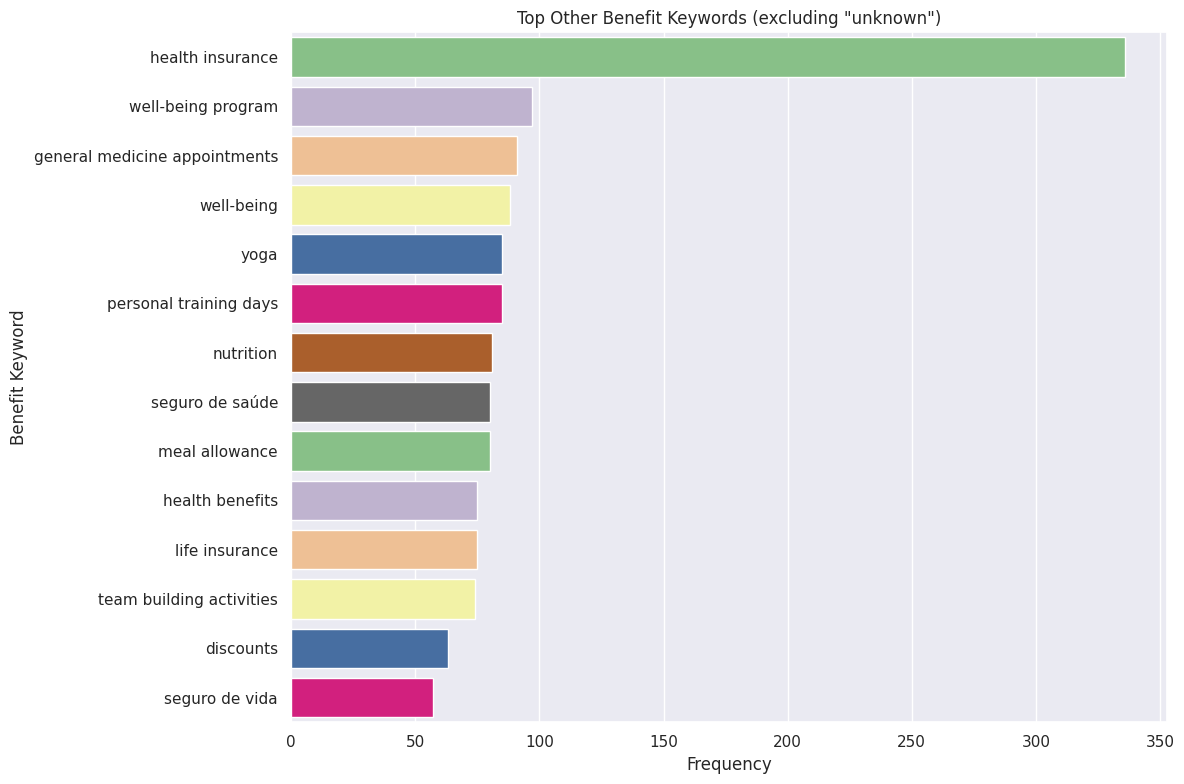

In [24]:
top_other_benefits = explode_and_count(df_bq, 'benefits.other_benefits_keywords', top_n=15)
if 'unknown' in top_other_benefits:
  top_other_benefits = top_other_benefits.drop('unknown', errors='ignore')


if not top_other_benefits.empty:
    plt.figure(figsize=(12,8)) # May need more height
    sns.barplot(y=top_other_benefits.index, x=top_other_benefits.values, palette="Accent")
    plt.title('Top Other Benefit Keywords (excluding "unknown")')
    plt.xlabel('Frequency')
    plt.ylabel('Benefit Keyword')
    plt.tight_layout()
    plt.show()
else:
    print("No other benefits data to plot (or only 'unknown' found).")